In [2]:
import numpy as np
import pandas as pd
import os, json
import random
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, linregress
import statsmodels.api as sm

DIRNAME = "Data"
NUM_AGENTS = 5
NUM_ROUNDS = 100

def open_file(dirname, file):

    if os.path.isdir(dirname):
        list = []
        filename = os.path.join(dirname, file)
        if os.path.exists(filename):
            with open(filename, "r") as f:
                for line in f:
                    list = json.loads(line)
                    break
    else:
        os.mkdir(dirname)
    
    return list

def save_file(dirname, file, list):
    
    filename = os.path.join(dirname, file)
    with open(filename, "w") as f:
        f.write(json.dumps(list, default=str))


In [10]:
#################################################
# Variational Bayes simulation of moral decision 
# situation based on a multi agent trust game
#################################################

# Hidden states
###############

hidden_states = [(s, o) for s in range(2) for o in range(5)]

#######################
#   Self    #  Other  #
#######################
#    0      #    0    #
#######################
#    0      #    1    #
#######################
#    0      #    2    #
#######################
#    0      #    3    #
#######################
#    0      #    4    #
#######################
#    1      #    0    #
#######################
#    1      #    1    #
#######################
#    1      #    2    #
#######################
#    1      #    3    #
#######################
#    1      #    4    #
#######################

# Constants
###########
ACTIONS = ['proportionate', 'disproportionate']
NUM_HIDDEN_STATES = len(hidden_states)

# Probabilities of actions given hidden states
both_prop_probs = [0.1, 0.15, 0.2, 0.25, 0.3, 0.2, 0.3, 0.4, 0.5, 0.6]
self_prop_other_disprop_probs = [0.3, 0.25, 0.2, 0.15, 0.1, 0.6, 0.5, 0.4, 0.3, 0.2]
self_disprop_other_prop_probs = [0.2, 0.3, 0.4, 0.5, 0.6, 0.1, 0.15, 0.2, 0.25, 0.3]
both_disprop_probs = [0.6, 0.5, 0.4, 0.3, 0.2, 0.3, 0.25, 0.2, 0.15, 0.1]

# Additions to probs given expectations
# Order: weakxweak, weakxmed, weakxstrong, medxweak, medxmed, medxstrong, strongxweak, strongxmed, strongxstrong
both_prop_adds = [0.198, 0.148, 0.098, 0.148, 0.123, 0.073, 0.098, 0.073, 0.048]
self_prop_other_disprop_adds = [0.098, 0.073, 0.048, 0.148, 0.123, 0.073, 0.198, 0.148, 0.098]
self_disprop_other_prop_adds = [0.098, 0.148, 0.198, 0.073, 0.123, 0.148, 0.048, 0.073, 0.098]
both_disprop_adds = [0.048, 0.073, 0.098, 0.073, 0.123, 0.148, 0.098, 0.148, 0.198]

# Quotients for weakening of expectations given hidden states
quotients_weak = [0.8, 0.85, 0.9, 0.95, 1.00, 0.85, 0.9, 0.95, 1.0, 1.0]

# Quotients for stengthening of expectations given relations
quotients_strong = [1.0, 1.2, 1.18, 1.08, 1.05]

# Data lists
tracked_expectations = []
tracked_exp_return = []
tracked_actions = []
tracked_beliefs = []
tracked_return_fracs = []
tracked_investments = []
tracked_returns = []
tracked_ressources = []
tracked_generosity = []
tracked_tot_rev = []
tracked_gen_rev = []
tracked_action_pairs = []

In [11]:
# Functions
###########
def softmax(x, tau=1.0):
    x = np.array(x)
    x -= np.max(x)
    e_x = np.exp(x / tau)
    return e_x / e_x.sum()

def expected_return(reaction_self, state_other, invest_other, rf, gen):

    # Compute expected return
    ######################################################
    # Expected return as a function of how the agent choose to react.
    # When the agent act proportinately the agent will satisfys
    # the expectations of others according the state (esteem) of the other 
    # and the return fraction (rf) from the last encounter with the other.
    # A multiplication factor is modulated according to esttem, if rf is 
    # higher or equal to 0. This should simulated the dividend of cooperation.  
    # If rf is less that 0, rf is modulated according to generosity. The
    # assumption is that more generous people would be more tolerant about
    # othr people not reprocicating.
    
    invest = invest_other if reaction_self == 'proportionate' else 0.0

    if rf >= 0:
        if state_other == 0:
            rf = 1 + (rf * 1)
        elif state_other == 1:
            rf = 1 + (rf * 1.5)
        elif state_other == 2:
            rf = 1 + (rf * 2.0)
        elif state_other == 3:
            rf = 1 + (rf * 2.5)
        elif state_other == 4:
            rf = 1 + (rf * 3)
    else:
        if gen < 0.73:
            rf = -1 + (rf * 1.5) 
        elif gen >= 0.73 and gen < 0.86:
            rf = -1 + rf
        else:
            rf = 1 + np.abs(rf)
    return rf * invest

def simulate_other_reaction(reaction_self, self_esteem, rf_agent):
    
    if reaction_self == 'proportionate':
        if rf_agent >= 0:
            if self_esteem == 1:   # Objective esteem
                prob = 0.9
            else:
                prob = 0.8
        else:
            prob = 0.00
    else:
        prob = 0.00
            
    return 'proportionate' if np.random.rand() < prob else 'disproportionate'

def possible_investments():

     # Get possible investments
    ############################
    investment_agents = []
    
    for i, agent in enumerate(agents):
        wage = agent['ressources']
        gen = agent['generosity']

        # Get list of expectations of the other agents
        expectation_other = []
        for o, other in enumerate(agents):
            if agent['number'] != o:
                for e, exp in enumerate(other['expectations']):
                    if e == agent['number']:
                        expectation_other.append(exp)
            else:
                expectation_other.append(0)
        
        sum_exp = sum(expectation_other)
        
        # Get percent value of expectations out of 
        # total expectations addressed to the agent (div)
        # and calculate investment (inv).
        investment = []
        for v in expectation_other:
            if sum_exp != 0:
                div = v/sum_exp
                inv = wage*0.6*gen*div
            else:
                inv = 0
            investment.append(inv)

        investment_agents.append(investment)

    return investment_agents

def compute_investments(agents):

    investment_agents = []
    
    for i, agent in enumerate(agents):
        wage = agent['ressources']
        gen = agent['generosity']

        # Get actions from agent towards others
        agents_to_other_action = agent['actions']

        # Get last actions of agent towards others
        agent_to_other_action = agents_to_other_action[-1]
        
        # Get list of expectations of the other agents
        expectation_other = []
        for o, other in enumerate(agents):

            # How did agent act towards other
            action = ''
            for k in agent_to_other_action:
                if other['number'] == k['agent']:
                    action = k['action']

            # The agent only invest if it acted proportionate
            if agent['number'] != o and action == 'proportionate':
                for e, exp in enumerate(other['expectations']):
                    if e == agent['number']:
                        expectation_other.append(exp)
            else:
                expectation_other.append(0)

        sum_exp = sum(expectation_other)

        # Get percent value of expectations out of 
        # total expectations addressed to the agent
        # and calculate investment (inv).
        investment = []
        for v in expectation_other:
            if sum_exp != 0:
                inv = wage*0.6*gen*(v/sum_exp)
            else:
                inv = 0
            investment.append(inv)

        investment_agents.append({'agent': agent['number'], 'inv': investment})

    return investment_agents

def actual_return(agents):

    investment_agents = compute_investments(agents)
    tracked_investments.append(investment_agents)

    net_return_agents = []
    return_fraction_agents = []
    total_revenue_round = []
    returns_agents = []
        
    # Get difference between investment and returns and return ratio
    ################################################################
    for w, inv in enumerate(investment_agents):  # For each agent
        net_return_agent = []
        return_fraction_agent = []
        returns_agent = []
    
        for q, que in enumerate(investment_agents):  # Find out how others invested in agent
            invest = inv['inv'][q]  # Get investment by agent in other
            for f, returns in enumerate(que['inv']):
                if w == f:  # If agent is the one the other invested in
                    re = returns-invest
                    returns_agent.append(returns)  # List of investments in agent by the other
                    net_return_agent.append(re)  # List of net returns: other's investment in agent minus agents investment in other
                    if invest != 0:
                        return_fraction_agent.append(re/invest)  # List of net returns as a percentage of investments
                    else:
                        return_fraction_agent.append(0)
                    
        net_return_agents.append(net_return_agent)
        return_fraction_agents.append(return_fraction_agent)
        returns_agents.append(returns_agent)

    tracked_returns.append(returns_agents)
    # Compute total revenue for each agent and round
    ################################################
    total_rev_agents = []

    for agent in agents:
        wage = agent['ressources']

        tot_ret = 0
        for r, ret in enumerate(net_return_agents):
            if r == agent['number']:
                tot_ret = sum(ret)

        tot_rev = wage + tot_ret
        total_rev_agents.append(tot_rev)

    tracked_tot_rev.append(total_rev_agents)

    """
    # Dataframes
    ############
    invest_viz = []
    for j in investment_agents:
        invest_viz.append(j['inv'])

    print("Agents investment in other agents")
    df_inv = pd.DataFrame(invest_viz, columns=['A0', 'A1', 'A2', 'A3', 'A4'], index=['A0', 'A1', 'A2', 'A3', 'A4'])
    df_inv['Total'] = df_inv.sum(axis=1)
    df_inv.style.set_table_attributes("style='display:inline'").set_caption("Agents investment in other agents")
    display(df_inv)

    print("Agents returns from other agents")
    df_ret = pd.DataFrame(returns_agents, columns=['A0', 'A1', 'A2', 'A3', 'A4'], index=['A0', 'A1', 'A2', 'A3', 'A4'])
    df_ret['Total'] = df_ret.sum(axis=1)
    df_ret.style.set_table_attributes("style='display:inline'").set_caption("Agents investment in other agents")
    display(df_ret)
    
    print("Agents net returns from other \nagents and total returns for agents")
    df = pd.DataFrame(net_return_agents, columns=['A0', 'A1', 'A2', 'A3', 'A4'], index=['A0', 'A1', 'A2', 'A3', 'A4'])
    df['Total'] = df.sum(axis=1)
    df.style.set_table_attributes("style='display:inline'").set_caption("Agents net returns from other \nagents and total returns for agents")
    display(df)

    print("Agents return fractions from other agents")
    df_frac = pd.DataFrame(return_fraction_agents, columns=['A0', 'A1', 'A2', 'A3', 'A4'], index=['A0', 'A1', 'A2', 'A3', 'A4'])
    df_frac['Average'] = df_frac.sum(axis=1)/4
    df_frac.style.set_table_attributes("style='display:inline'").set_caption("Agents return fractions from other agents")
    display(df_frac)
    """

    # Return return ratios
    ######################
    return return_fraction_agents

def reaction(expectation):

    exp = ''
    
    if expectation < 0.25:
        exp =  'weak'
    elif expectation >= 0.25 and expectation < 0.5:
        exp = 'medium'
    elif expectation >= 0.5:
        exp = 'strong'

    return exp

def observation(action_self, action_other, expectation_self, expectation_other):

    obs_action = ''
    obs_exp = 0
    
    if action_self == 'proportionate' and action_other == 'proportionate':
        obs_action = 'both_proportionate'
    elif action_self == 'proportionate' and action_other == 'disproportionate':
        obs_action = 'self_proportionate_other_disproportionate'
    elif action_self == 'defect' and action_other == 'proportionate':
        obs_action = 'self_disproportionate_other_proportionate'
    elif action_self == 'disproportionate' and action_other == 'disproportionate':
        obs_action = 'both_disproportionate'
    else:
        obs_action = 'start'

    exp_s = reaction(expectation_self)
    exp_o = reaction(expectation_other)

    if exp_s == 'weak' and exp_o == 'weak':
        obs_exp = 0
    elif exp_s == 'weak' and exp_o == 'medium':
        obs_exp = 1
    elif exp_s == 'weak' and exp_o == 'strong':
        obs_exp = 2
    elif exp_s == 'medium' and exp_o == 'weak':
        obs_exp = 3
    elif exp_s == 'medium' and exp_o == 'medium':
        obs_exp = 4
    elif exp_s == 'medium' and exp_o == 'strong':
        obs_exp = 5
    elif exp_s == 'strong' and exp_o == 'weak':
        obs_exp = 6
    elif exp_s == 'strong' and exp_o == 'medium':
        obs_exp = 7
    elif exp_s == 'strong' and exp_o == 'strong':
        obs_exp = 8
    
    return obs_action, obs_exp
        
def likelihood(obs, state):

    # Return likelihood of observation given state (partly through expectations).
    
    lik = 0
    st_num = 0
    action, expect = obs

    for i, st in enumerate(hidden_states):
        if state == st:
            st_num = i
    
    if action == 'both_proportionate':
        lik = both_prop_probs[st_num] + (both_prop_adds[expect] * quotients_weak[st_num])
    elif action == 'self_proportionate_other_disproportionate':
        lik = self_prop_other_disprop_probs[st_num] + (self_prop_other_disprop_adds[expect] * quotients_weak[st_num])
    elif action == 'self_disproportionate_other_proportionate':
        lik = self_disprop_other_prop_probs[st_num] + (self_disprop_other_prop_adds[expect] * quotients_weak[st_num])
    elif action == 'both_disproportionate':
        lik = both_disprop_probs[st_num] + (both_disprop_adds[expect] * quotients_weak[st_num])
    else: 
        lik = 0.1

    return lik

def vb_update(lambda_z, obs, hidden_states, likelihood, lr=0.1):
    
    # Current variational distribution
    q = softmax(lambda_z)

    # Gradient computation
    grad = np.zeros_like(lambda_z)
    for i, state in enumerate(hidden_states):
        log_lik = np.log(likelihood(obs, state) + 1e-8)
        grad[i] = log_lik - np.log(q[i] + 1e-8)
        
    # Update step
    lambda_new = lambda_z + lr * grad
    q_new = softmax(lambda_new)
    
    return lambda_new, q_new

"""
# Bayesian updating in an exponential family, the natural gradient update would be an alternative
# This one is more directly tied to Bayes’ rule and avoids the unstable “log-lik - log-q” subtraction.

def vb_update_natgrad(lambda_z, obs, hidden_states, likelihood, lr=0.1):
    q = softmax(lambda_z)
    log_lik = np.array([np.log(likelihood_fn(obs, s) + 1e-8) for s in hidden_states])
    unnorm_post = q * np.exp(log_lik)
    q_post = unnorm_post / np.sum(unnorm_post)
    lambda_new = (1 - lr) * lambda_z + lr * np.log(q_post + 1e-8)
    return lambda_new, q_post
"""
                                         
def generate_generosity_rate():

	# Number indicates rate of generosity
	# The probability of smaller generosity should be larger
    ########################################################
	
    float_array = np.linspace(0.61, 0.99, num=39)
    list = np.around(float_array, 2).tolist()
    weights = list[::-1]
    gen = random.choices(list, weights=weights, k=1)
    generosity = np.array(gen).item()
     		
    return generosity

def generate_ressources(agents):

    # Number indicates the size of the ressources invested in 
    # satisfying the expectations of other agents.
    # We assume these ressorces are 

    res = []
    for i, agent in enumerate(agents):
        agent['ressources'] = random.randint(20, 40)
        res.append(agent['ressources'])

    tracked_ressources.append(res)

def create_relations_matrix():

    # Create relations matrix
    # 0 : no relation
    # 1 : close family
    # 2 : close friend
    # 3 : remote family
    # 4 : remote friend, acquaintance
    # We assume these relations to be reciprocal
    # The relation cannot at the same time be close and remote,
    # family and fried; these are thus exclusive relations
    # These relations are created randomly but with weights favoring 0 (no relation)
    
    agents = np.arange(0, NUM_AGENTS).tolist()
    weights = [5, 1, 1, 1, 2]
    matrix = []
    
    for j in combinations(agents, 2):
    
        comb = [j, random.choices(agents, weights=weights, k=1)]
        matrix.append(comb)

    return matrix

def generate_expectations(agents):

    # Expectations can take values between 0.01 and 0.99
    # This value indicates intensity of expectation
	# This include importance, urgency, effort, obligation ...
	# The probability of smaller intensity should be larger
    # 0 < exp < 0.25 : non-obligatory, good to do, but no urgency
    # 0.25 =< exp < 0.5 : non-obligatory, good to do and important
    # 0.5 =< exp < 1.0 : obligatory
    #######################################################

    list_temp = []
    
    for i, agent in enumerate(agents):

        list_temp.append(agent['expectations'])
        agent['expectations'].clear()
        
        for t in range(NUM_AGENTS):

            if t == i:
                agent['expectations'].append(0)
            else:

                # Determine relation
                ####################
                relation = 0
                
                tup1 = (i, t)
                tup2 = (t, i)

                for r in relations:
                    if r[0] == tup1 or r[0] == tup2:
                        relation = r[1][0]

                # Create expectations
                #####################
                
                float_array = np.linspace(0.01, 0.99, num=99)
                list = np.around(float_array, 2).tolist()
                weights = list[::-1]
                exp = random.choices(list, weights=weights, k=1)
                expectation = np.array(exp).item()
                
                expectation = expectation * quotients_strong[relation]
                
                agent['expectations'].append(expectation)

    tracked_expectations.append(list_temp)

def compute_esteem(agents, agent_number, other_number):

    other_esteem = 0
    self_esteem = 0
    other_numb = 0

    other_list = np.arange(0, 5, 1).tolist()
    other_list.pop(agent_number)

    for ln, n_belief in enumerate(other_list):
        if n_belief == other_number:
            other_numb = ln

    state = np.argmax(agents[agent_number]['belief'][other_numb])

    if state > 4:
        self_esteem = 1

    if state < 5:
        other_esteem == state
    else: 
        other_esteem == state - 5

    return other_esteem, self_esteem

def compute_objective_esteem(agents, agent_number):

    other_esteem = 0
    self_esteem = 0

    gen = agents[agent_number]['generosity']

    if gen < 0.87:
        self_esteem = 0
    elif gen >= 0.87 and gen < 1.00:
        self_esteem = 1

    if gen < 0.69:
        other_esteem = 0
    elif gen >= 0.69 and gen < 0.77:
        other_esteem = 1
    elif gen >= 0.77 and gen < 0.85:
        other_esteem = 2
    elif gen >= 0.85 and gen < 0.93:
        other_esteem = 3
    elif gen >= 0.93 and gen < 1.00:
        other_esteem = 4
    
    return other_esteem, self_esteem
    

In [12]:
def beliefs ():

    tracked_beliefs = open_file(DIRNAME, "beliefs_in_others_proportionality.json")
    agent_data = open_file(DIRNAME, "agent_data.json")
    
    all_res = []
    
    for agent in range(NUM_AGENTS):
        
        list = np.arange(0, NUM_AGENTS, 1).tolist()
        list.pop(agent)
        
        other_data = []
        
        for other, item in enumerate(list):
       
            viz_data = []
            
            for i in range(10):
                data = []
                                
                for round, d in enumerate(tracked_beliefs):
                    
                    s = d[agent][other][i]
                    data.append(s)

                x = np.arange(0, len(data)).tolist()
                
                slope, intercept, rv, p, se = linregress(x, data)

                sign = ''
                
                if p < 0.05:
                    if slope >= 0:
                        sign = '+'
                    else:
                        sign = '-'
                else:
                    sign = 'o'
                    
                viz_data.append([agent, item, i, sign])
                
            other_data.append(viz_data)
        agent_data.append(other_data)
          
    save_file(DIRNAME, "agent_data.json", agent_data)

In [13]:
def ect_s(agent, other):
    real = 0
    o, s = compute_objective_esteem(agents, agent)
    
    if np.argmax(agents[agent]['belief'][other]) < 5:
        real = 0
    else:
        real = 1
        
    dev_s = real - s

    return dev_s

In [14]:
def ect_o(agent, other):
    real = 0
    o, s = compute_objective_esteem(agents, other)

    if np.argmax(agents[agent]['belief'][other]) < 5:
        real = np.argmax(agents[agent]['belief'][other])
    else:
        real = np.argmax(agents[agent]['belief'][other]) - 5
        
    dev_o = real - o

    return dev_o

In [15]:
def precision ():

    gen = open_file(DIRNAME, "generosity.json")
    gen = gen[-1]
    
    tracked_precision = open_file(DIRNAME, "precision.json")
    
    # List with following elements: generosity, agent number, other number, deviation self, deviation other, other number ...
    list = [
    [gen[0], 0, 1, ect_s(0, 0), ect_o(0, 0), 2, ect_s(0, 1), ect_o(0, 1), 3, ect_s(0, 2), ect_o(0, 2), 4, ect_s(0, 3), ect_o(0, 3)],
    [gen[1], 1, 0, ect_s(1, 0), ect_o(1, 0), 2, ect_s(1, 1), ect_o(1, 1), 3, ect_s(1, 2), ect_o(1, 2), 4, ect_s(1, 3), ect_o(1, 3)],
    [gen[2], 2, 0, ect_s(2, 0), ect_o(2, 0), 1, ect_s(2, 1), ect_o(2, 1), 3, ect_s(2, 2), ect_o(2, 2), 4, ect_s(2, 3), ect_o(2, 3)],
    [gen[3], 3, 0, ect_s(3, 0), ect_o(3, 0), 1, ect_s(3, 1), ect_o(3, 1), 2, ect_s(3, 2), ect_o(3, 2), 4, ect_s(3, 3), ect_o(3, 3)],
    [gen[4], 4, 0, ect_s(4, 0), ect_o(4, 0), 1, ect_s(4, 1), ect_o(4, 1), 2, ect_s(4, 2), ect_o(4, 2), 3, ect_s(4, 3), ect_o(4, 3)]
    ]
    
    tracked_precision.append(list)
    
    save_file(DIRNAME, "precision.json", tracked_precision)

In [16]:
GAMES = 100

for i in range(GAMES):

    # Open data files
    #################
    tracked_gen_rev = open_file(DIRNAME, "tracked_gen_rev.json")
    tracked_gen_act = open_file(DIRNAME, "tracked_gen_act.json")
    
    if tracked_return_fracs:
        return_frac = tracked_return_fracs[-1]
    else:
        return_frac = []

    # Initialize agents
    ###################
    agents = []
    
    for i in range(NUM_AGENTS):
        lam = np.zeros(NUM_HIDDEN_STATES)
        b_list = []
        s_list = []
        for p in range(NUM_AGENTS-1):
            b_list.append(lam)
            s_list.append(softmax(lam))
            
        agents.append({
            'number': i,
            'lambda': b_list, #lam,
            'belief': s_list, #softmax(lam),
            'actions': [],
            'expectations': [],
            'generosity': generate_generosity_rate(),
            'ressources': 0
        })

    # Save generosity rates
    #######################
    gen = []
    for agent in agents:
        gen.append(agent['generosity'])
    tracked_generosity.append(gen)
        
    # Create relations matrix
    #########################
    relations = create_relations_matrix()

    ############
    # Simulation
    ############
    np.random.seed(42)
    for t in range(NUM_ROUNDS):
    
        # Generate expectations for all agents towards all
        # the other agents for this round
        generate_expectations(agents)
    
        # Generate ressorces for each agent for this round
        generate_ressources(agents)
        
        exp_return_agents = []
        action_agents = []
        belief_agents = []
        action_pairs_agents = []
    
        investment_agents = possible_investments()

        # Take one agent at the time
        for i in range(NUM_AGENTS):
            agent = agents[i]
            exp_return_agent = []
            action_agent = []
            belief_agent = []
            action_pairs_agent = []
            
            # Decide what to accept for each other agent
            for o in range(NUM_AGENTS):
                if o != i:
                    other = agents[o]
                    other_numb = 0
    
                    other_list = np.arange(0, 5, 1).tolist()
                    other_list.pop(agent['number'])
    
                    for ln, n_belief in enumerate(other_list):
                        if n_belief == o:
                            other_numb = ln

                    # Decision
                    ###################
                    # For actions 'proportionate' and 'disproportionate' evaluate 
                    # probability for the agent (other)
    
                    #Get possible investment
                    invest_other = investment_agents[agent['number']][other['number']]
    
                    # Get return fraction other if it exist
                    if return_frac:
                        rf = return_frac[agent['number']][other['number']]
                    else:
                        rf = 0.6
                        
                    # Get return fraction agent if it exist
                    if return_frac:
                        rf_agent = return_frac[other['number']][agent['number']]
                    else:
                        rf_agent = 0.6
    
                    # Get agent generosity
                    genro = agent['generosity']

                    # Get q-values
                    q_vals = []
                    exp_ret_other = []
                    for action in ACTIONS:
                        belief_times_exp = []
                        exp_ret_actions = []
                        for j, s in enumerate(hidden_states):
                            exp_ret = expected_return(action, s[1], invest_other, rf, genro)
                            exp_ret_actions.append(exp_ret)
                            belief_times_exp.append(agent['belief'][other_numb][j] * exp_ret)
                            
                        ev = sum(belief_times_exp)
                        q_vals.append(ev)
                        exp_ret_other.append(exp_ret_actions)
                    exp_return_agent.append(exp_ret_other)
    
                    # Compute objective esteem
                    other_o_esteem, self_o_esteem = compute_objective_esteem(agents, agent['number'])
    
                    # Compute actions
                    a_self = np.random.choice(ACTIONS, p=softmax(q_vals, tau=0.5))
                    a_other = simulate_other_reaction(a_self, self_o_esteem, rf_agent)
    
                    action_pairs_agent.append([a_self, a_other])
                               
                    # Compute observations
                    s_numb = agent['number']
                    o_numb = other['number']
                    obs = observation(a_self, a_other, agent['expectations'][o_numb], other['expectations'][s_numb])
                    
                    # VB Update
                    agent['lambda'][other_numb], agent['belief'][other_numb] = vb_update(agent['lambda'][other_numb], obs, hidden_states, likelihood)
            
                    # Track
                    belief_agent.append(agent['belief'][other_numb].tolist())
                    action_agent.append({'agent': o, 'action': a_self})
            
            exp_return_agents.append(exp_return_agent)
            action_agents.append(action_agent)
            belief_agents.append(belief_agent)
            action_pairs_agents.append(action_pairs_agent)
            
            agent['actions'].append(action_agent)
            if len(agent['actions']) > 5:
                agent['actions'].pop(0)
    
    
        return_frac = actual_return(agents)
    
        tracked_beliefs.append(belief_agents)
        tracked_return_fracs.append(return_frac)
        tracked_actions.append(action_agents)
        tracked_exp_return.append(exp_return_agents)
        tracked_action_pairs.append(action_pairs_agents)
        

    # Save data
    #########################
    save_file(DIRNAME, "actions_towards_others.json", tracked_actions)
    save_file(DIRNAME, "beliefs_in_others_proportionality.json", tracked_beliefs)
    save_file(DIRNAME, "return_fracs.json", tracked_return_fracs)
    save_file(DIRNAME, "ressources.json", tracked_ressources)
    save_file(DIRNAME, "generosity.json", tracked_generosity)
    save_file(DIRNAME, "expectations.json", tracked_expectations)
    save_file(DIRNAME, "expected_return.json", tracked_exp_return)
    save_file(DIRNAME, "investments.json", tracked_investments)
    save_file(DIRNAME, "returns.json", tracked_returns)
    save_file(DIRNAME, "total_revenue.json", tracked_tot_rev)
    save_file(DIRNAME, "total_revenue.json", tracked_tot_rev)
    save_file(DIRNAME, "action_pairs.json", tracked_action_pairs)

    # Average ressouces
    ###################
    all_res = []
    for q in range(NUM_AGENTS):
        tot_res = []
        for rv in tracked_ressources:
            tot_res.append(rv[q])
        all_res.append(sum(tot_res)/NUM_ROUNDS)
    
    # Average total revenue
    ###############
    all_rev = []
    for p in range(NUM_AGENTS):
        tot_rev = []
        for r in tracked_tot_rev:
            tot_rev.append(r[p])
        all_rev.append(sum(tot_rev)/NUM_ROUNDS)

    # Actions
    #########
    all_act = []
    for a in range(NUM_AGENTS):
        agent_act = []
        for round in tracked_actions:
            for agent in round:
                for act in agent:
                    if act['agent'] == a:
                        if act['action'] == "proportionate":
                            agent_act.append(1)
                        else:
                            agent_act.append(0)
        all_act.append(sum(agent_act)/len(agent_act))
    
    def est(number):
        o, s = compute_objective_esteem(agents, number)
        return str(o) + "-" + str(s)

    # Presentation of results
    #########################
    print('################################################################')
    print('# Agent      #   0     #   1     #   2     #  3      #   4     #')
    print('################################################################')
    print('# Generosity #  %.2f   #  %.2f   #  %.2f   #  %.2f   #  %.2f   # ' % (agents[0]['generosity'], agents[1]['generosity'], agents[2]['generosity'], agents[3]['generosity'], agents[4]['generosity']))
    print('################################################################')
    print('# Other/self #  %s    #  %s    #  %s    #  %s    #  %s    # ' % (est(agents[0]['number']), est(agents[1]['number']), est(agents[2]['number']), est(agents[3]['number']), est(agents[4]['number'])))
    print('################################################################')
    print('# Avg res    #  %.2f  #  %.2f  #  %.2f  #  %.2f  #  %.2f  #' % (all_res[0], all_res[1], all_res[2], all_res[3], all_res[4]))
    print('################################################################')
    print('# Avg rev    #  %.2f  #  %.2f  #  %.2f  #  %.2f  #  %.2f  #' % (all_rev[0], all_rev[1], all_rev[2], all_rev[3], all_rev[4]))
    print('################################################################')
    print('# Prop freq* #  %.2f   #  %.2f   #  %.2f   #  %.2f   #  %.2f   #' % (all_act[0], all_act[1], all_act[2], all_act[3], all_act[4]))
    print('################################################################')
    print('# * Proportion at which others act proportionally towards it   #')
    print('################################################################')

    if tracked_gen_rev:
        tracked_gen_rev[0].append(agents[0]['generosity'])
        tracked_gen_rev[0].append(agents[1]['generosity'])
        tracked_gen_rev[0].append(agents[2]['generosity'])
        tracked_gen_rev[0].append(agents[3]['generosity'])
        tracked_gen_rev[0].append(agents[4]['generosity'])
        tracked_gen_rev[1].append(all_rev[0]-all_res[0])
        tracked_gen_rev[1].append(all_rev[1]-all_res[1])
        tracked_gen_rev[1].append(all_rev[2]-all_res[2])
        tracked_gen_rev[1].append(all_rev[3]-all_res[3])
        tracked_gen_rev[1].append(all_rev[4]-all_res[4])
    else:
        tracked_gen_rev.append([agents[0]['generosity'], agents[1]['generosity'], agents[2]['generosity'], agents[3]['generosity'], agents[4]['generosity']])
        tracked_gen_rev.append([all_rev[0]-all_res[0], all_rev[1]-all_res[1], all_rev[2]-all_res[2], all_rev[3]-all_res[3], all_rev[4]-all_res[4]])
    
    save_file(DIRNAME, "tracked_gen_rev.json", tracked_gen_rev)
    
    if tracked_gen_act:
        tracked_gen_act[0].append(agents[0]['generosity'])
        tracked_gen_act[0].append(agents[1]['generosity'])
        tracked_gen_act[0].append(agents[2]['generosity'])
        tracked_gen_act[0].append(agents[3]['generosity'])
        tracked_gen_act[0].append(agents[4]['generosity'])
        tracked_gen_act[1].append(all_act[0])
        tracked_gen_act[1].append(all_act[1])
        tracked_gen_act[1].append(all_act[2])
        tracked_gen_act[1].append(all_act[3])
        tracked_gen_act[1].append(all_act[4])
    else:
        tracked_gen_act.append([agents[0]['generosity'], agents[1]['generosity'], agents[2]['generosity'], agents[3]['generosity'], agents[4]['generosity']])
        tracked_gen_act.append([all_act[0], all_act[1], all_act[2], all_act[3], all_act[4]])

    save_file(DIRNAME, "tracked_gen_act.json", tracked_gen_act)

    beliefs()
    precision()



################################################################
# Agent      #   0     #   1     #   2     #  3      #   4     #
################################################################
# Generosity #  0.82   #  0.88   #  0.81   #  0.61   #  0.97   # 
################################################################
# Other/self #  2-0    #  3-1    #  2-0    #  0-0    #  4-1    # 
################################################################
# Avg res    #  29.12  #  30.16  #  30.13  #  29.60  #  30.94  #
################################################################
# Avg rev    #  27.76  #  30.12  #  28.08  #  35.35  #  28.64  #
################################################################
# Prop freq* #  0.75   #  0.70   #  0.75   #  0.76   #  0.70   #
################################################################
# * Proportion at which others act proportionally towards it   #
################################################################
#######################

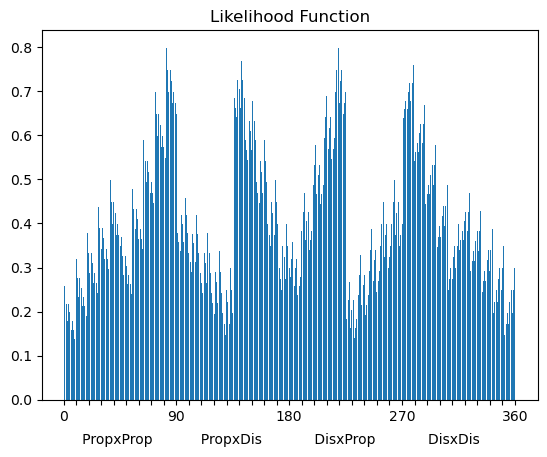

In [17]:
import matplotlib.pyplot as plt

# Probabilities of actions given hidden states
both_prop_probs = [0.1, 0.15, 0.2, 0.25, 0.3, 0.2, 0.3, 0.4, 0.5, 0.6]
self_prop_other_disprop_probs = [0.3, 0.25, 0.2, 0.15, 0.1, 0.6, 0.5, 0.4, 0.3, 0.2]
self_disprop_other_prop_probs = [0.2, 0.3, 0.4, 0.5, 0.6, 0.1, 0.15, 0.2, 0.25, 0.3]
both_disprop_probs = [0.6, 0.5, 0.4, 0.3, 0.2, 0.3, 0.25, 0.2, 0.15, 0.1]

# Additions to probs given expectations
# Order: weakxweak, weakxmed, weakxstrong, medxweak, medxmed, medxstrong, strongxweak, strongxmed, strongxstrong
both_prop_adds = [0.198, 0.148, 0.098, 0.148, 0.123, 0.073, 0.098, 0.073, 0.048]
self_prop_other_disprop_adds = [0.098, 0.073, 0.048, 0.148, 0.123, 0.073, 0.198, 0.148, 0.098]
self_disprop_other_prop_adds = [0.098, 0.148, 0.198, 0.073, 0.123, 0.148, 0.048, 0.073, 0.098]
both_disprop_adds = [0.048, 0.073, 0.098, 0.073, 0.123, 0.148, 0.098, 0.148, 0.198]

# Quotients for weakening of expectations given hidden states
quotients_weak = [0.8, 0.85, 0.9, 0.95, 1.00, 0.85, 0.9, 0.95, 1.0, 1.0]

all_probs = []

for i, item in enumerate(both_prop_probs):
    for s in both_prop_adds:
        prob = item + (s  * quotients_weak[i])
        
        all_probs.append(prob)


for i, item in enumerate(self_prop_other_disprop_probs):
    for s in self_prop_other_disprop_adds:
        prob = item + (s  * quotients_weak[i])
        all_probs.append(prob)


for i, item in enumerate(self_disprop_other_prop_probs):
    for s in self_disprop_other_prop_adds:
        prob = item + (s  * quotients_weak[i])
        all_probs.append(prob)


for i, item in enumerate(both_disprop_probs):
    for s in both_disprop_adds:
        prob = item + (s  * quotients_weak[i])
        all_probs.append(prob)


#print(all_probs)
plt.bar(np.arange(1, 361, 1), all_probs)
plt.title('Likelihood Function')
plt.xticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360], ['0', "", "", "", "", "", "", "", "", '90', "", "", "", "", "", "", "", "", '180', "", "", "", "", "", "", "", "", '270', "", "", "", "", "", "", "", "", '360'],
       rotation=0)
plt.text(4.0, -0.1, '   PropxProp           PropxDis            DisxProp            DisxDis')
#['']
plt.show();



###########################################################################################################################
# Agent 0 / other 1 / state 0: slope +1.46E-06 - intercept 9.89E-02 - Pearsonr +1.56E-01 - p-value 1.87E-55 - SE 9.25E-08 #
###########################################################################################################################
# Agent 0 / other 1 / state 1: slope +9.95E-07 - intercept 9.46E-02 - Pearsonr +1.61E-01 - p-value 3.75E-59 - SE 6.09E-08 #
###########################################################################################################################
# Agent 0 / other 1 / state 2: slope +5.71E-07 - intercept 8.89E-02 - Pearsonr +1.69E-01 - p-value 5.00E-65 - SE 3.33E-08 #
###########################################################################################################################
# Agent 0 / other 1 / state 3: slope +1.84E-07 - intercept 8.18E-02 - Pearsonr +1.11E-01 - p-value 5.71E-29 - SE 1.64E-08 #
########

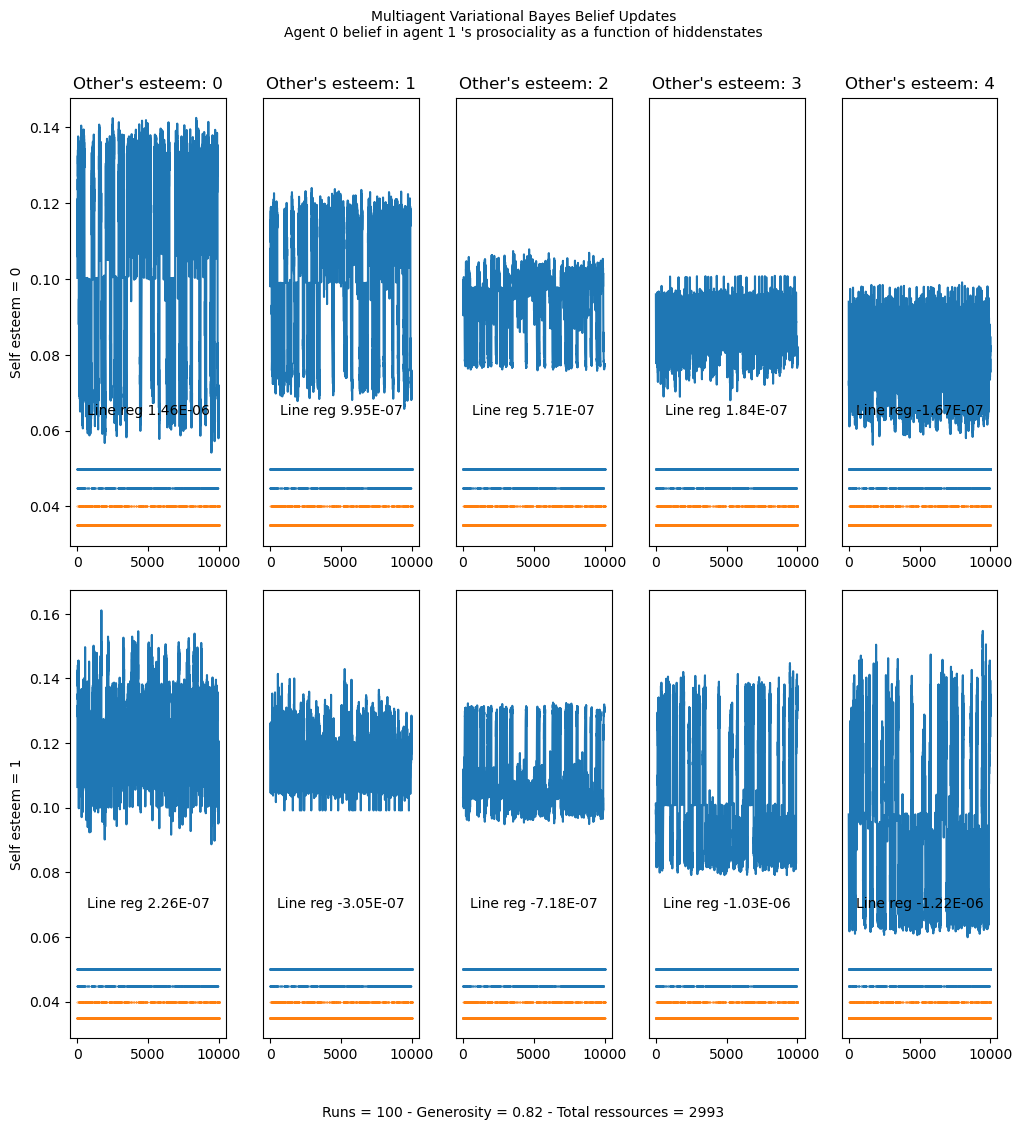

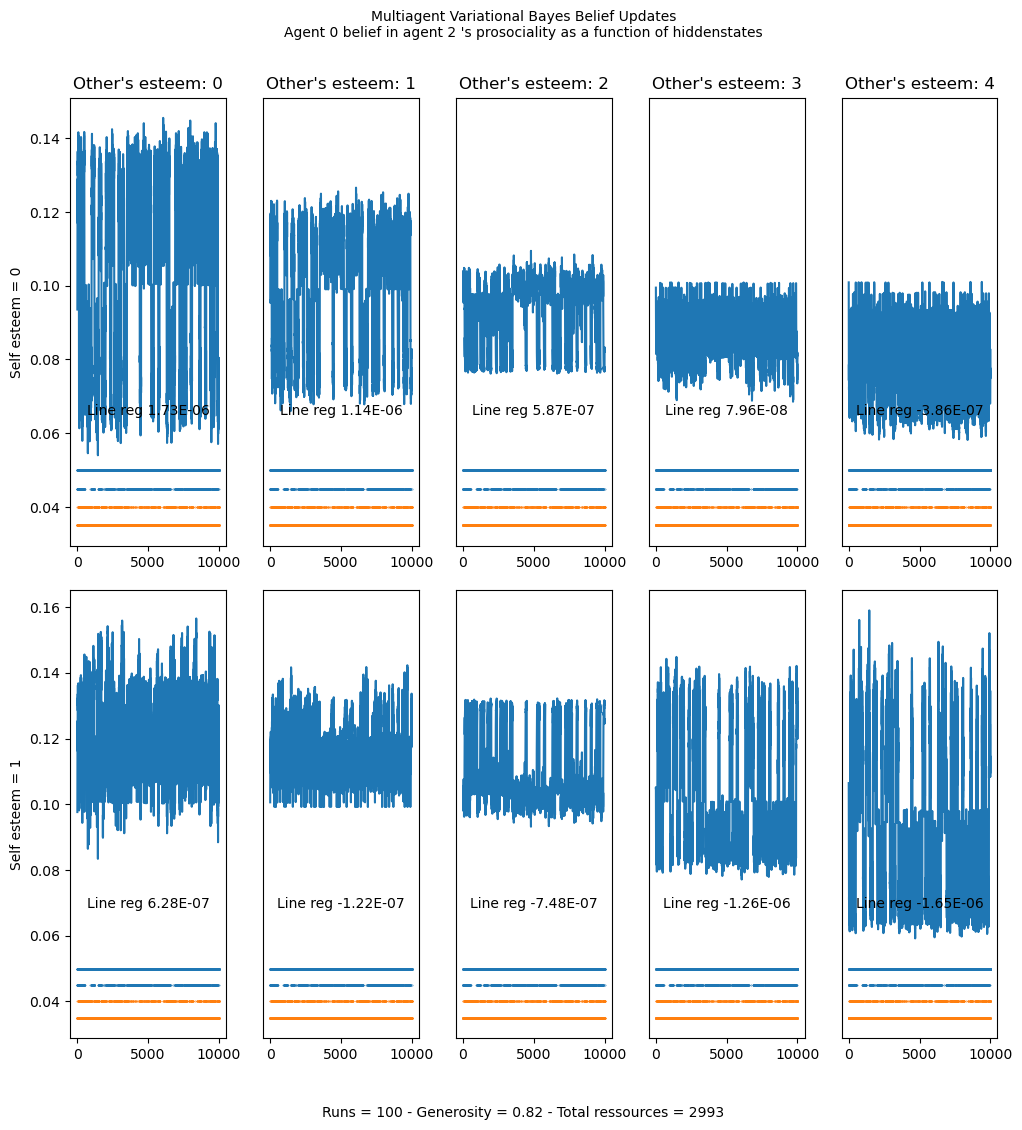

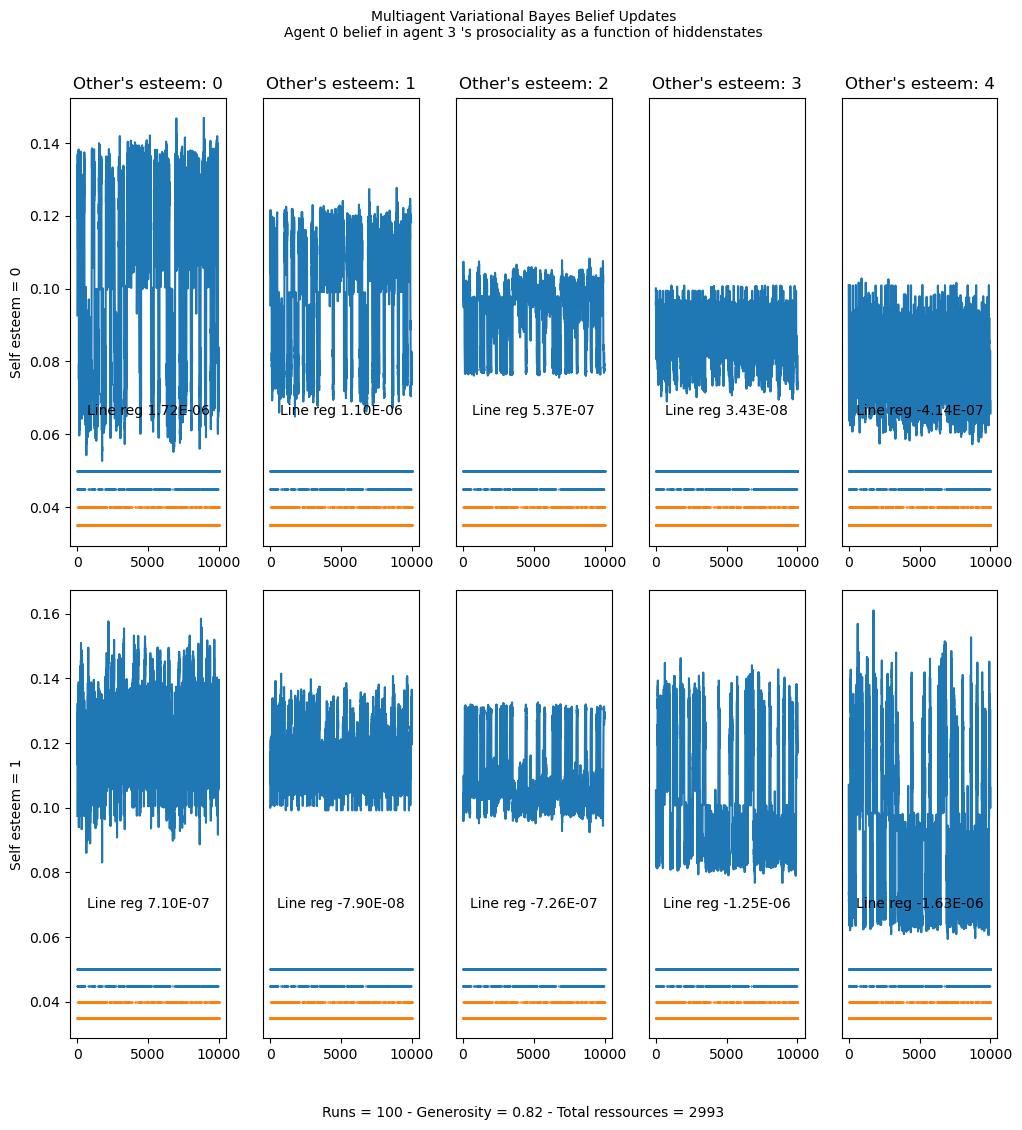

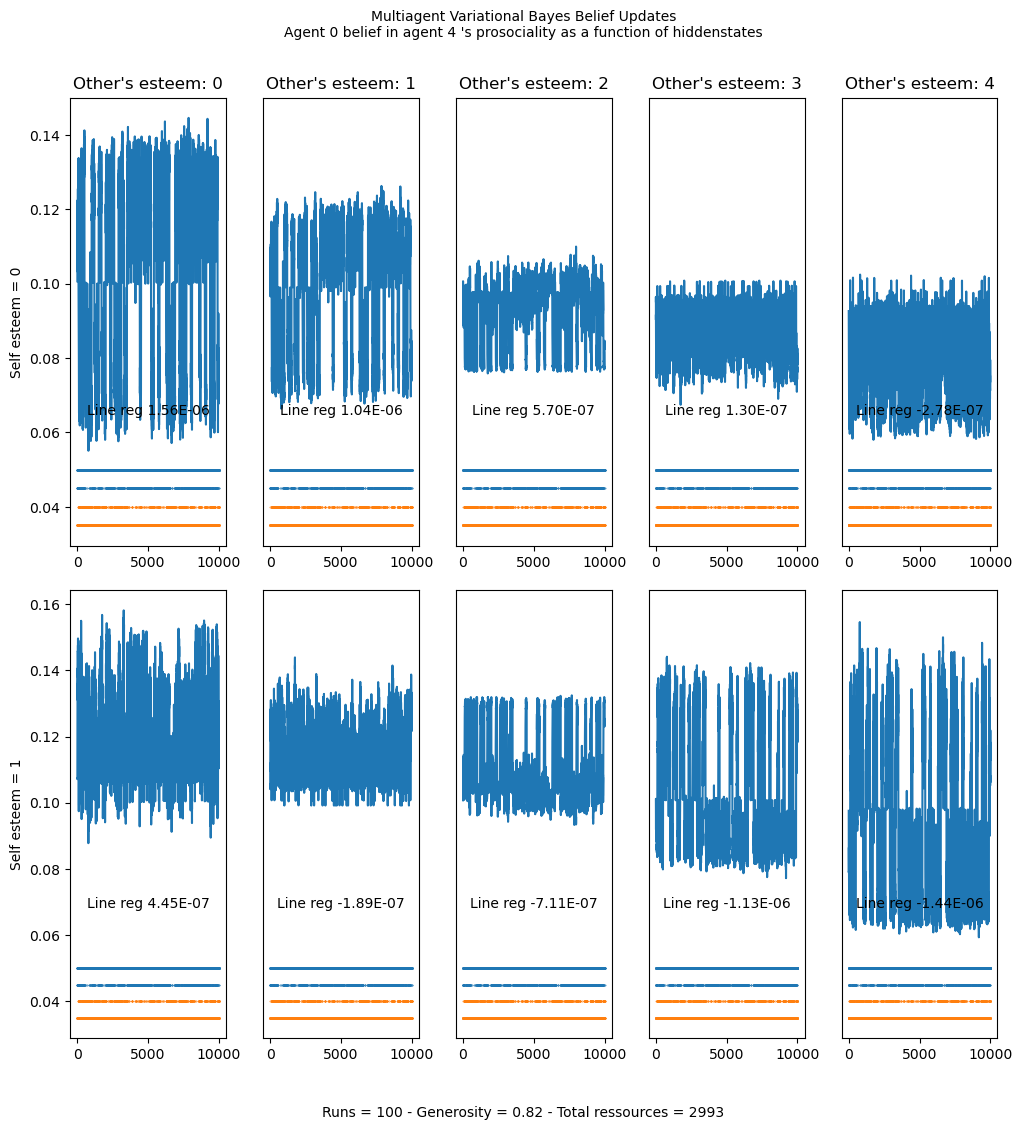

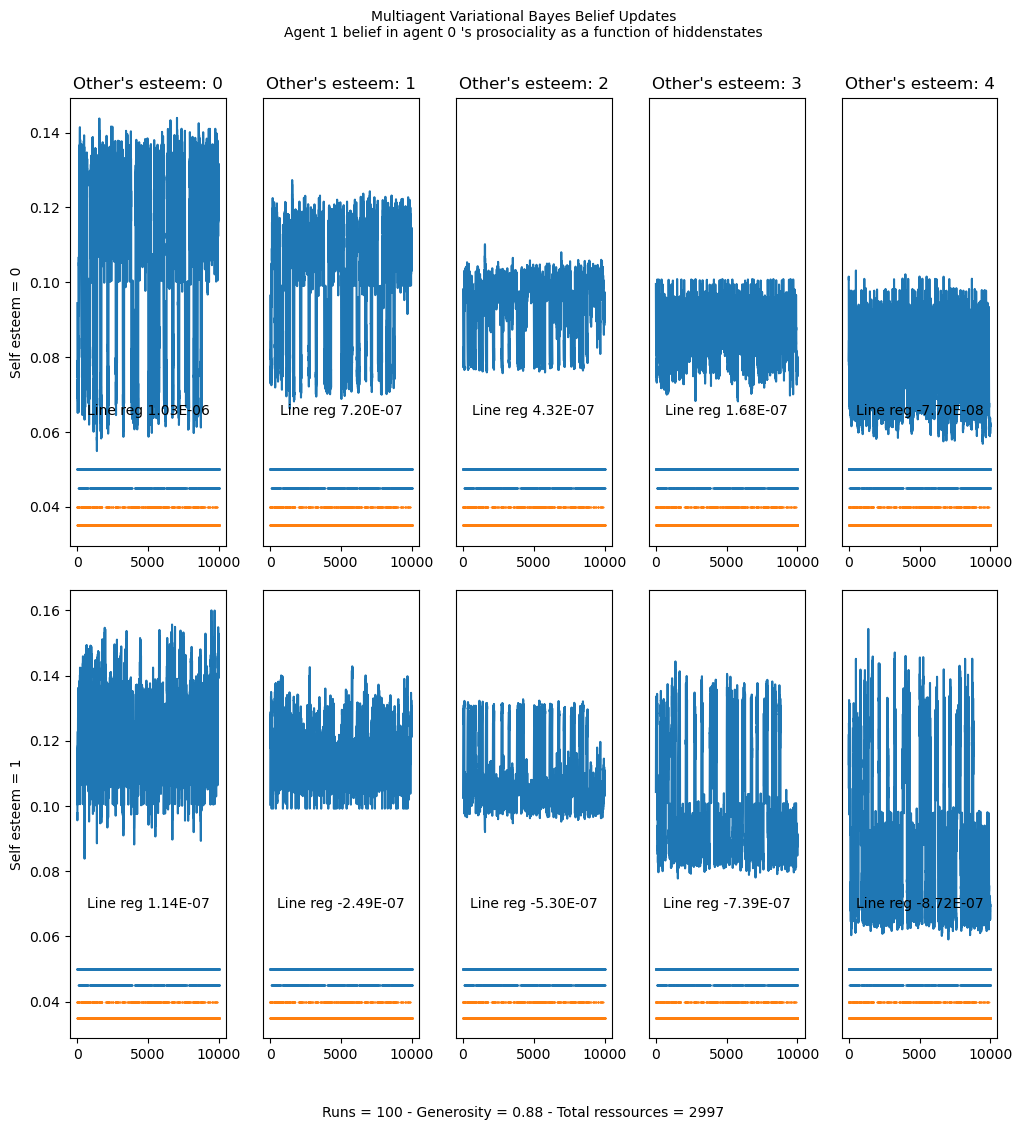

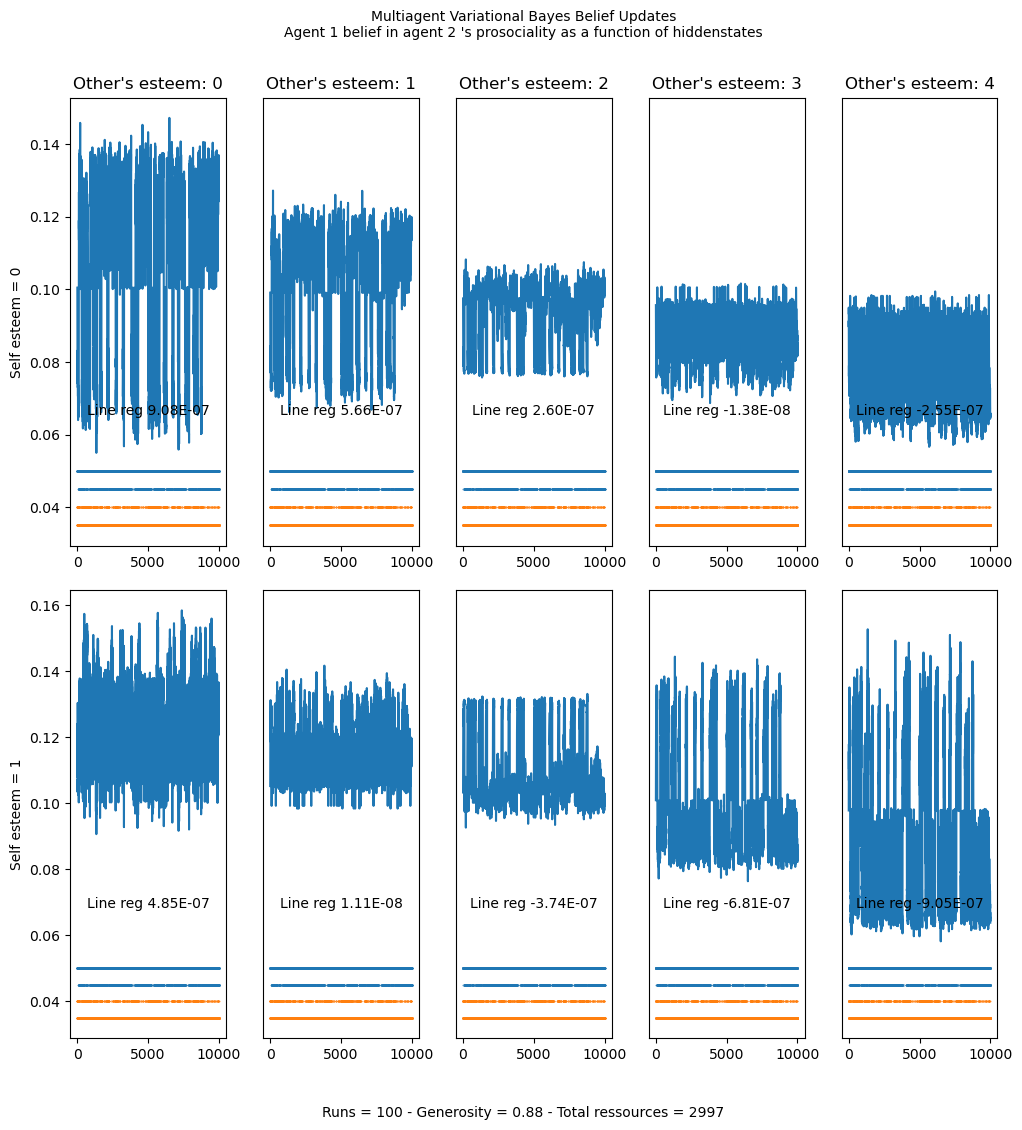

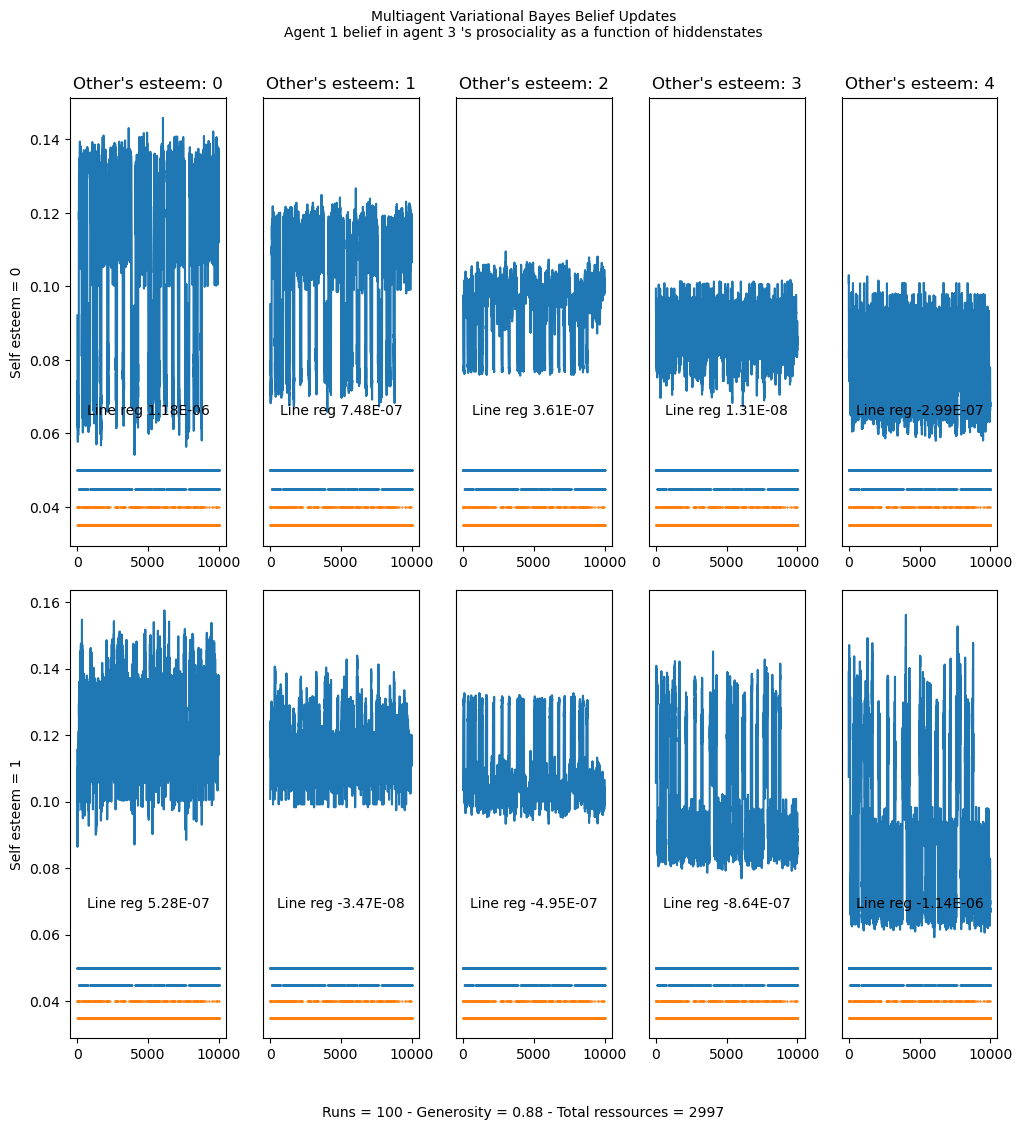

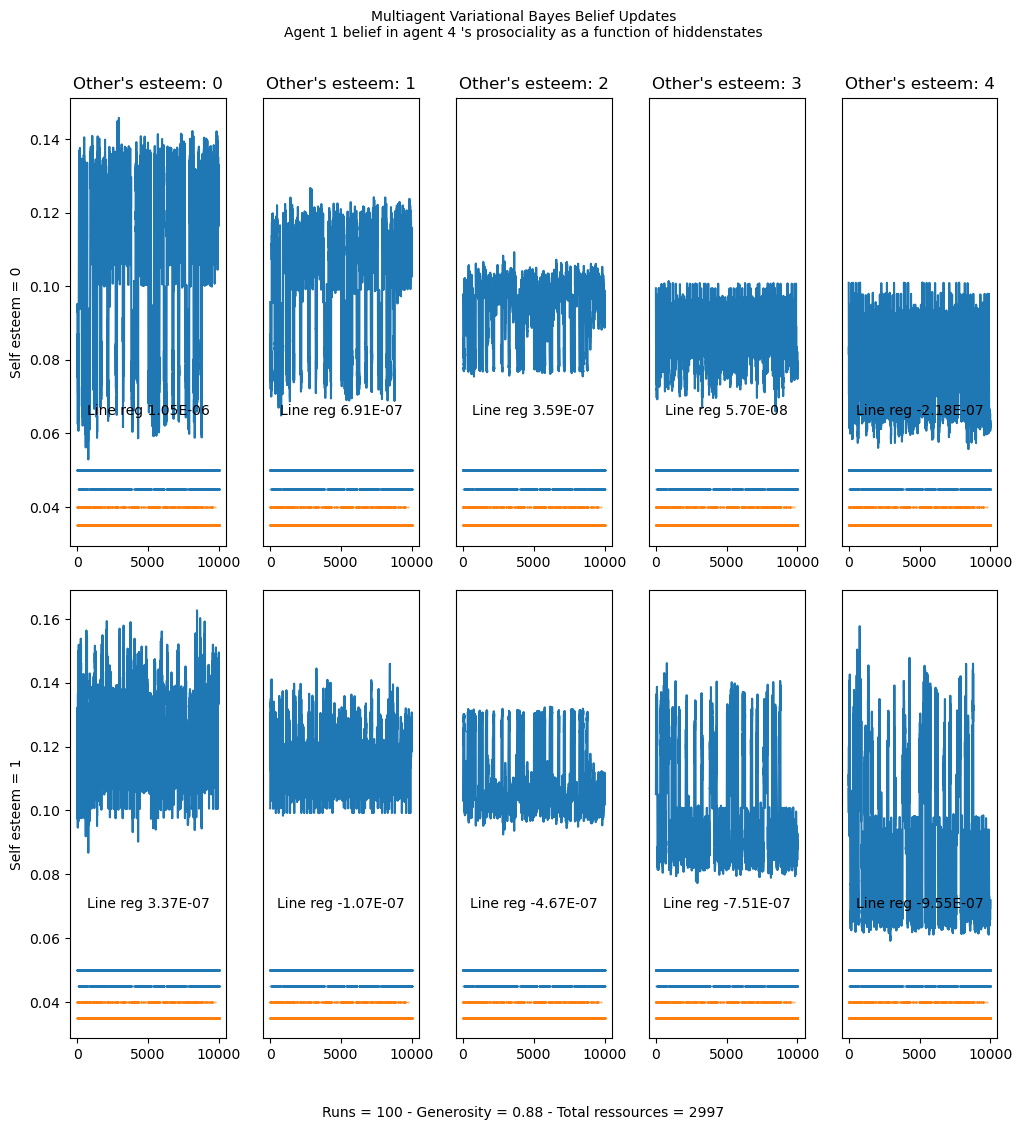

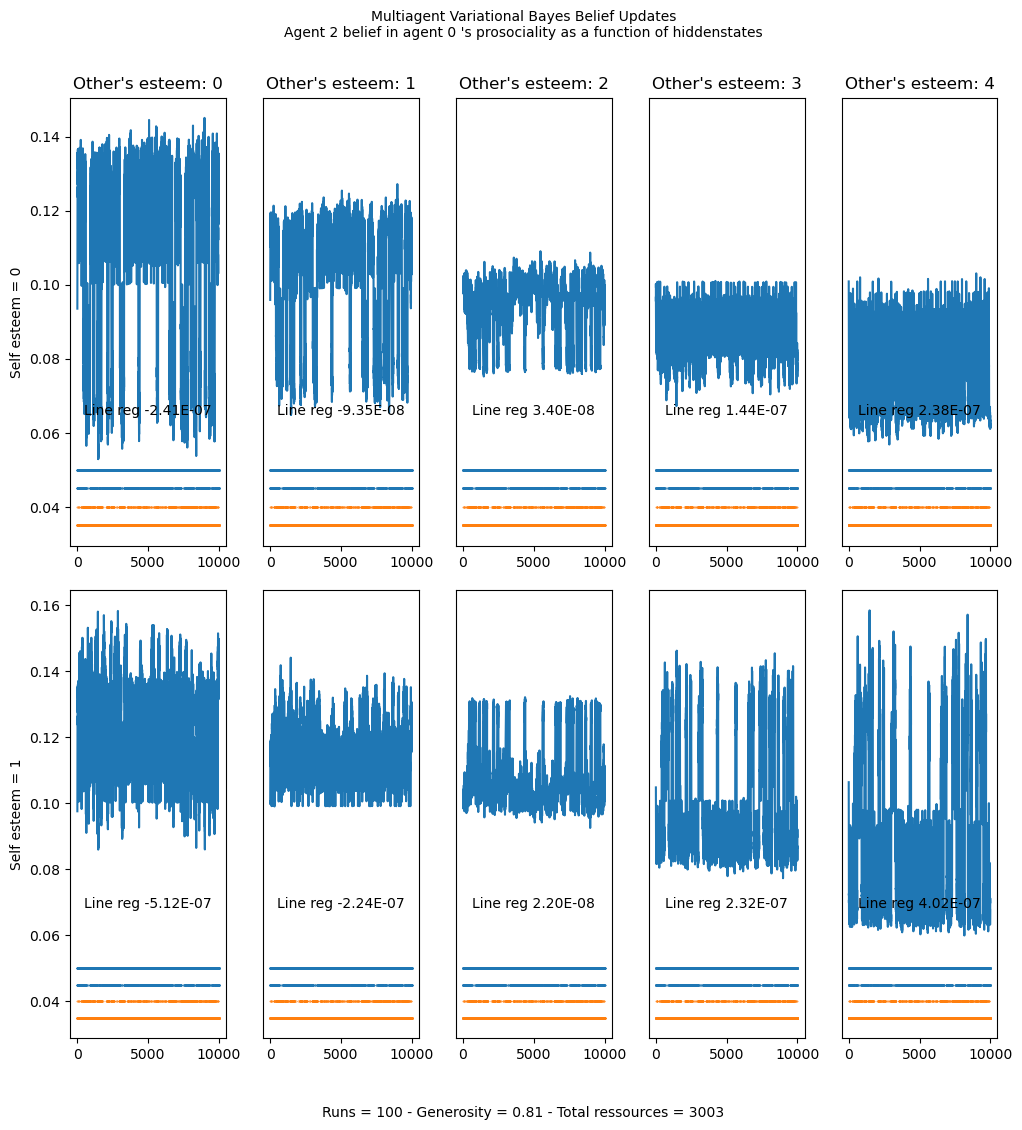

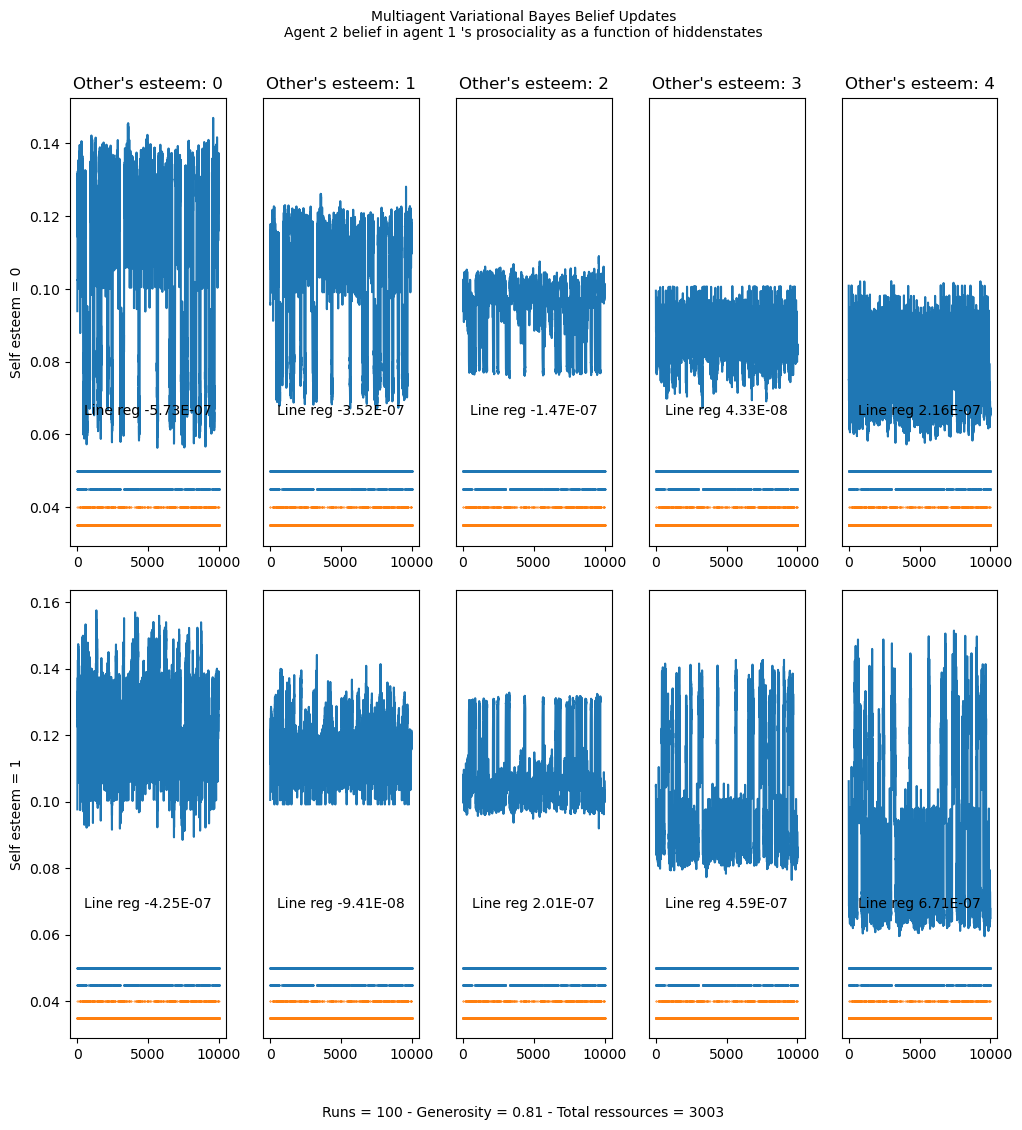

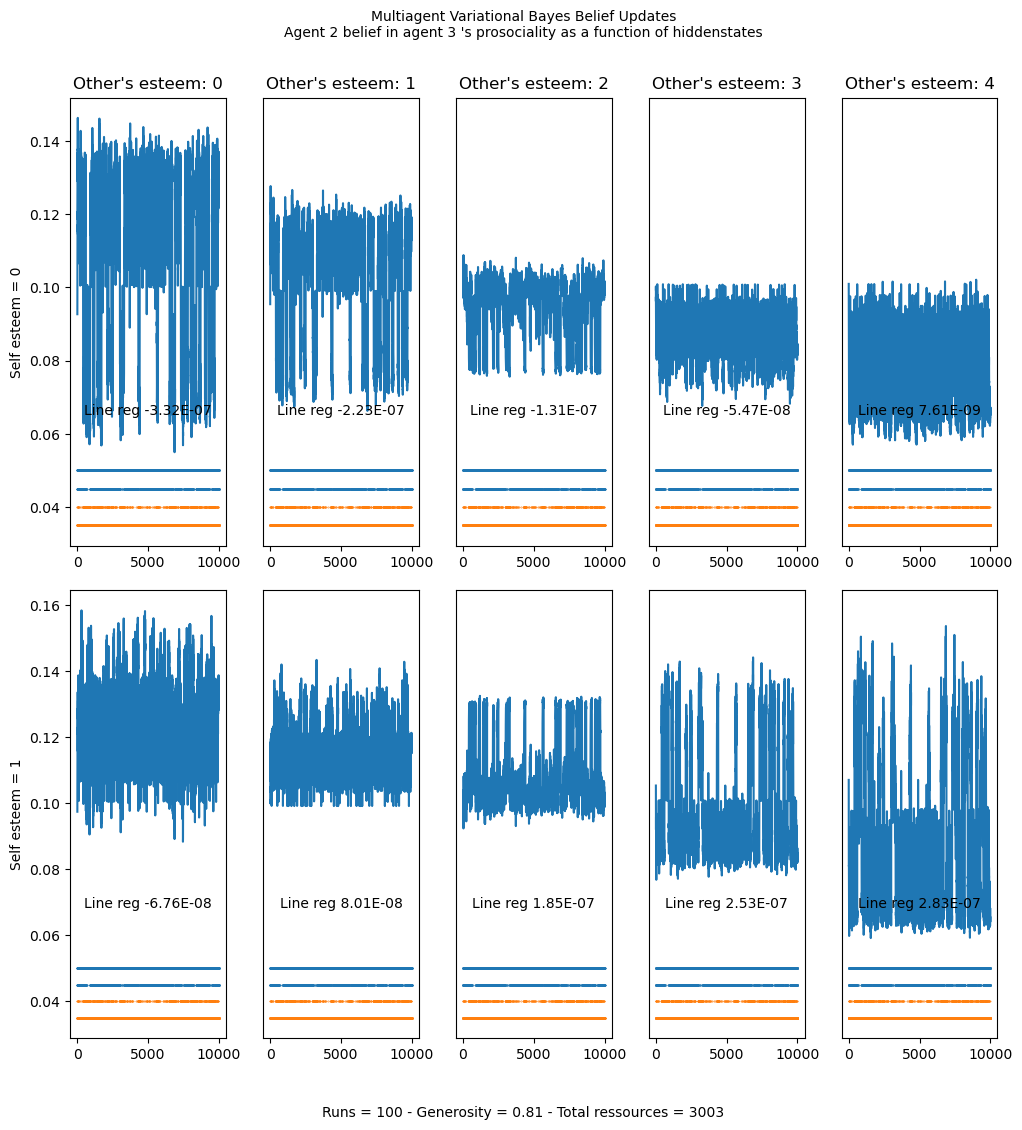

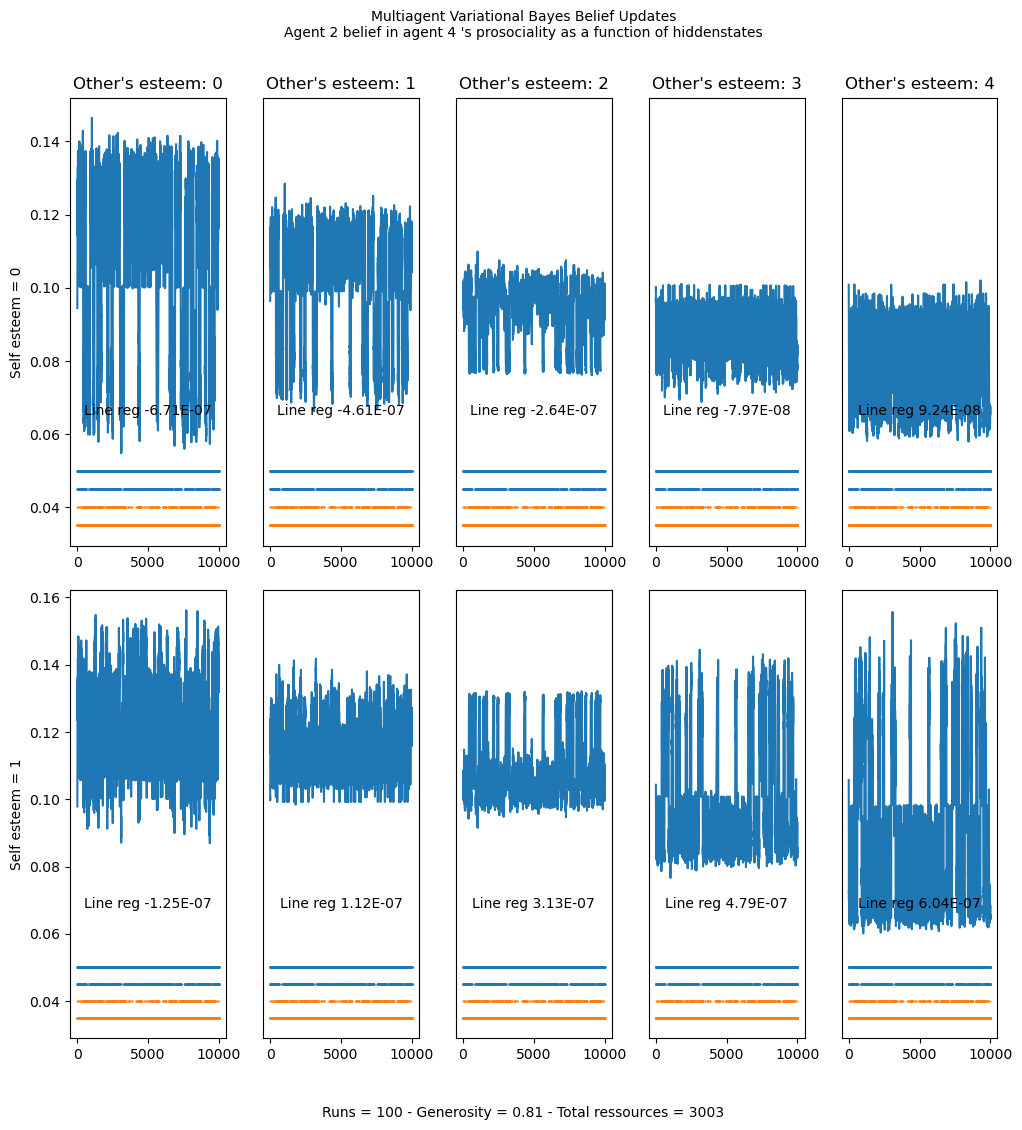

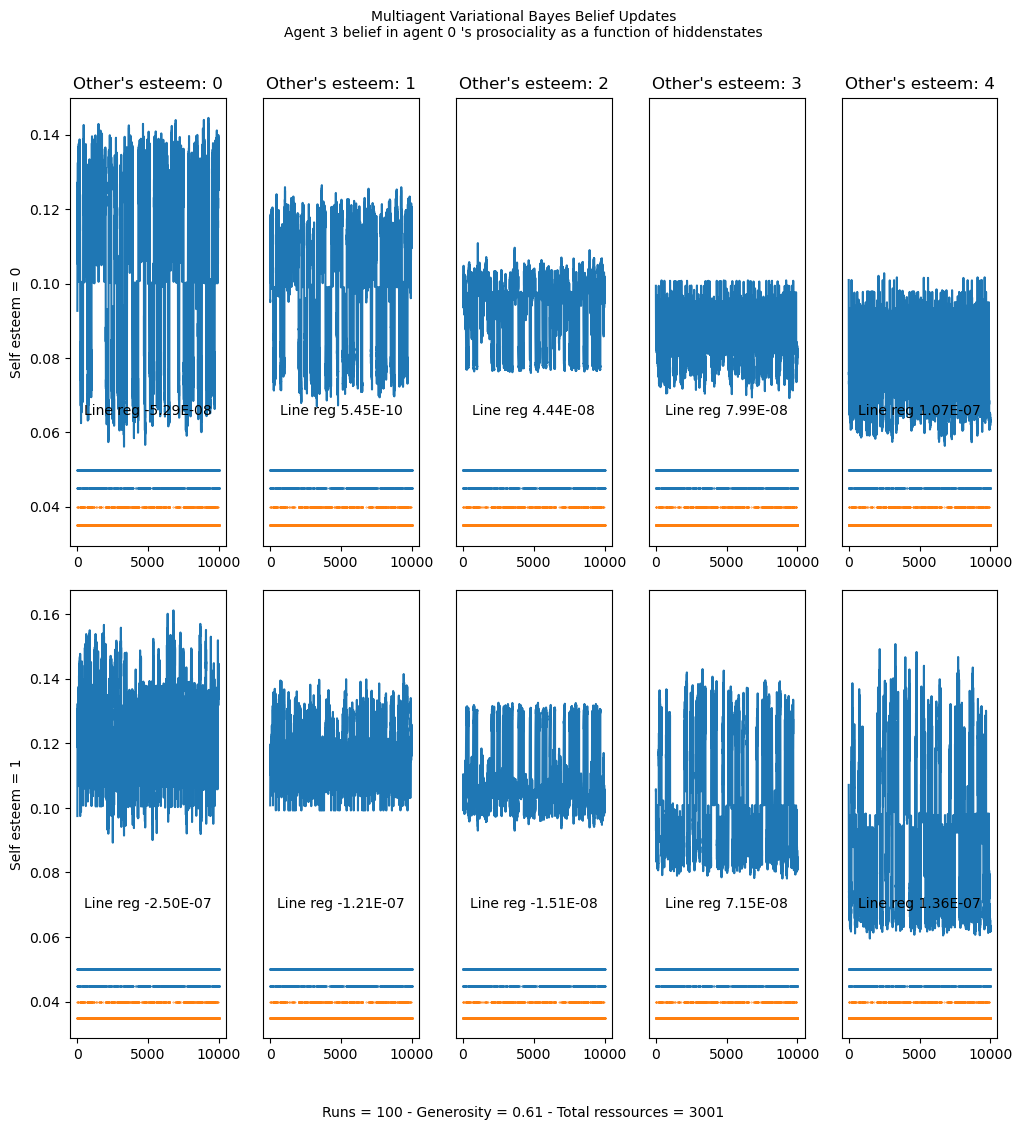

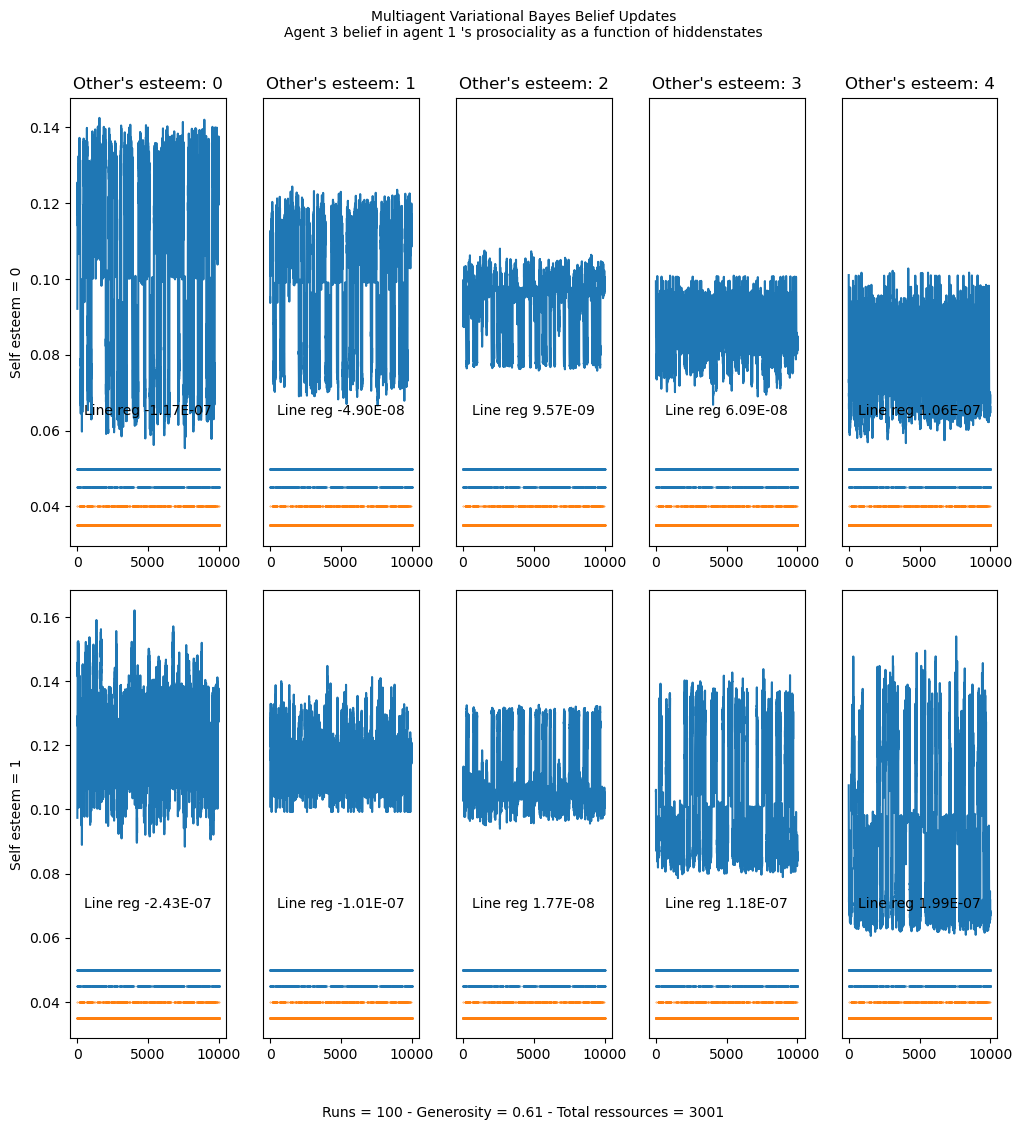

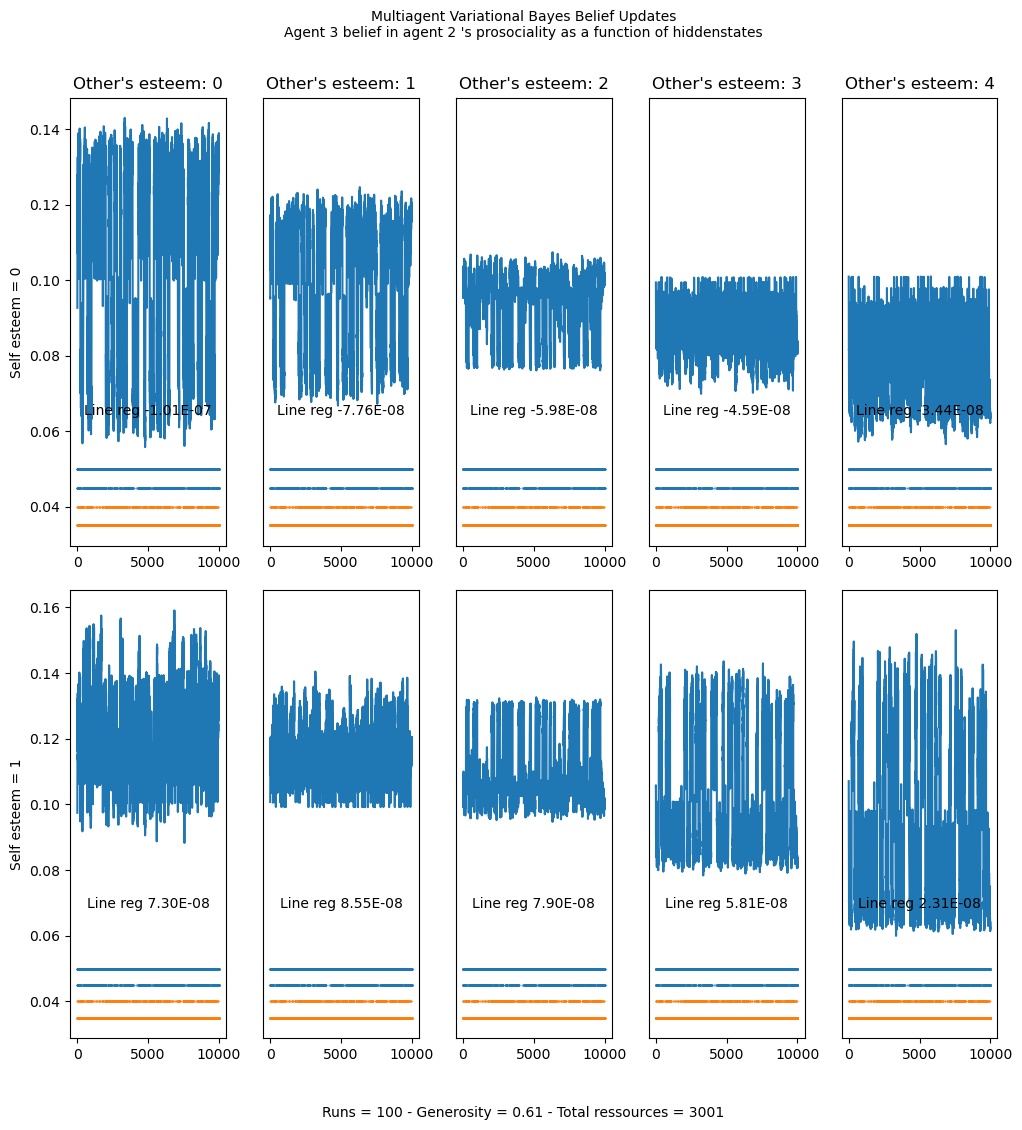

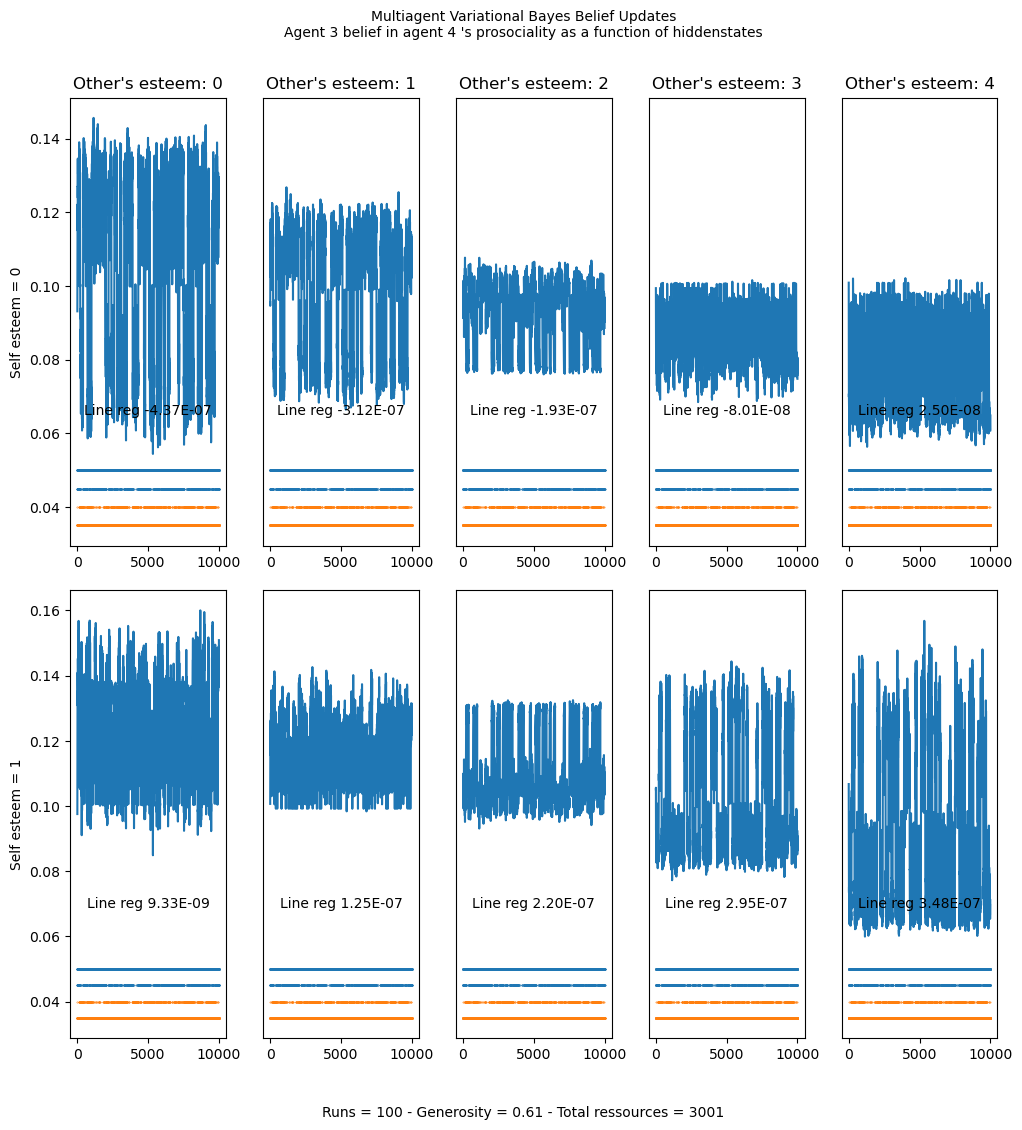

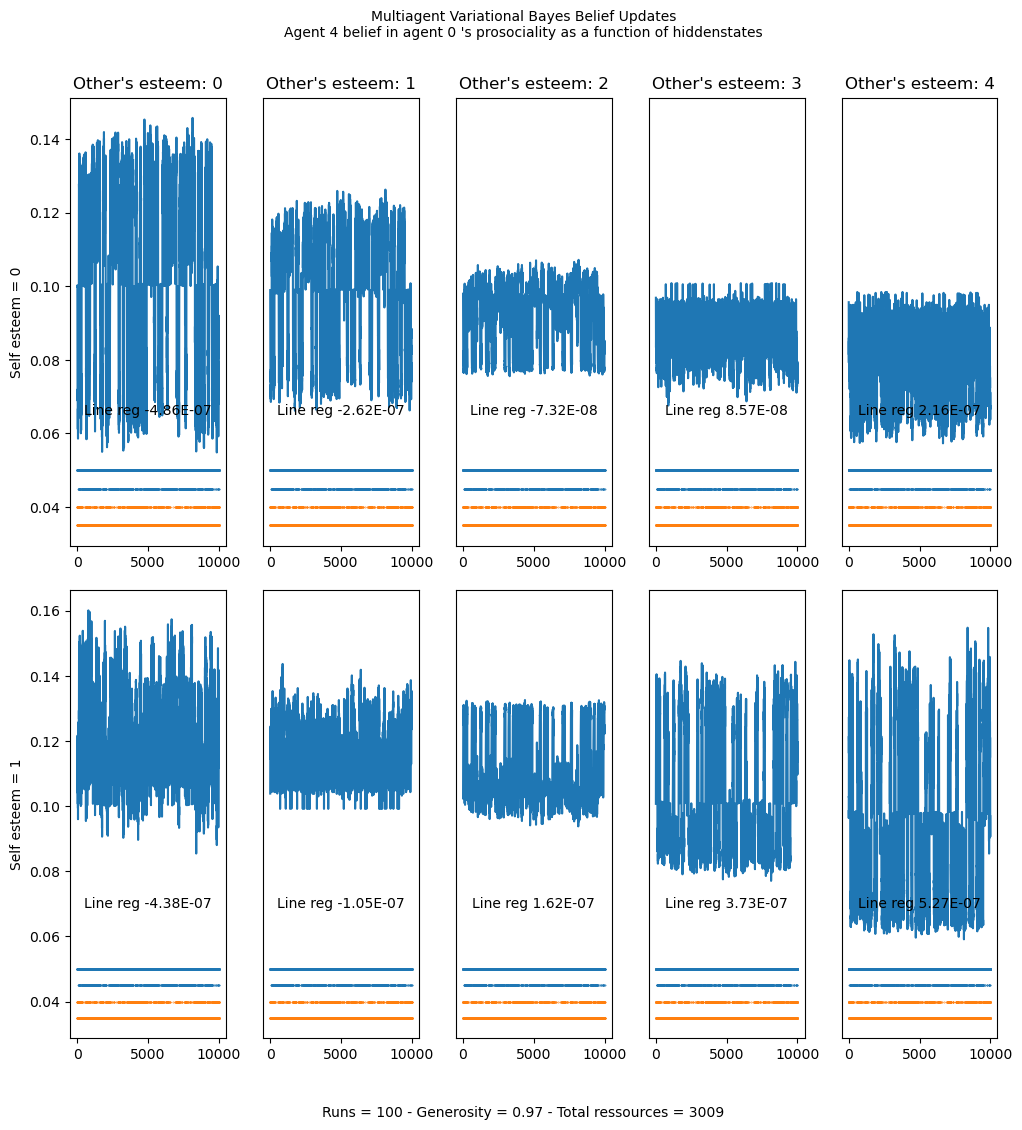

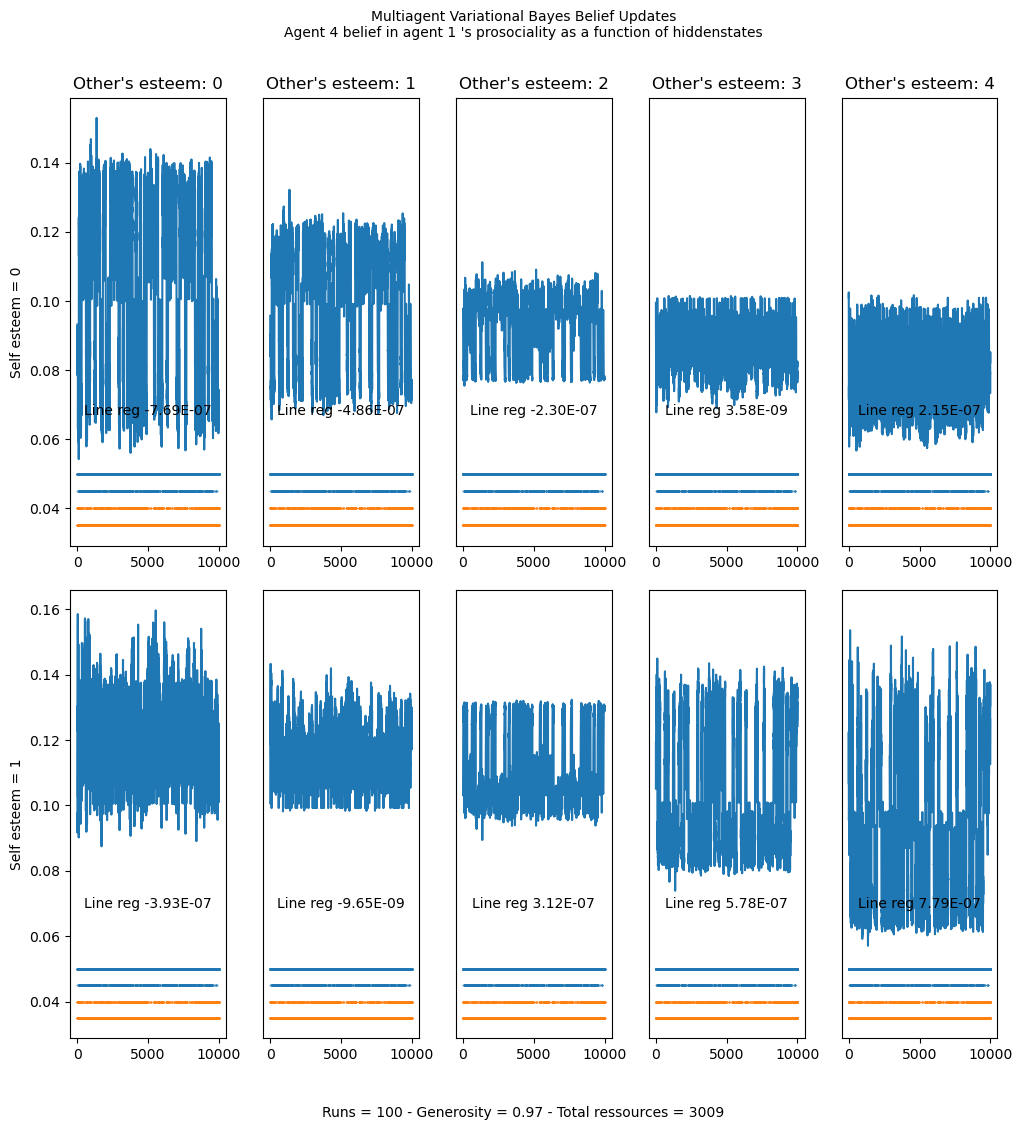

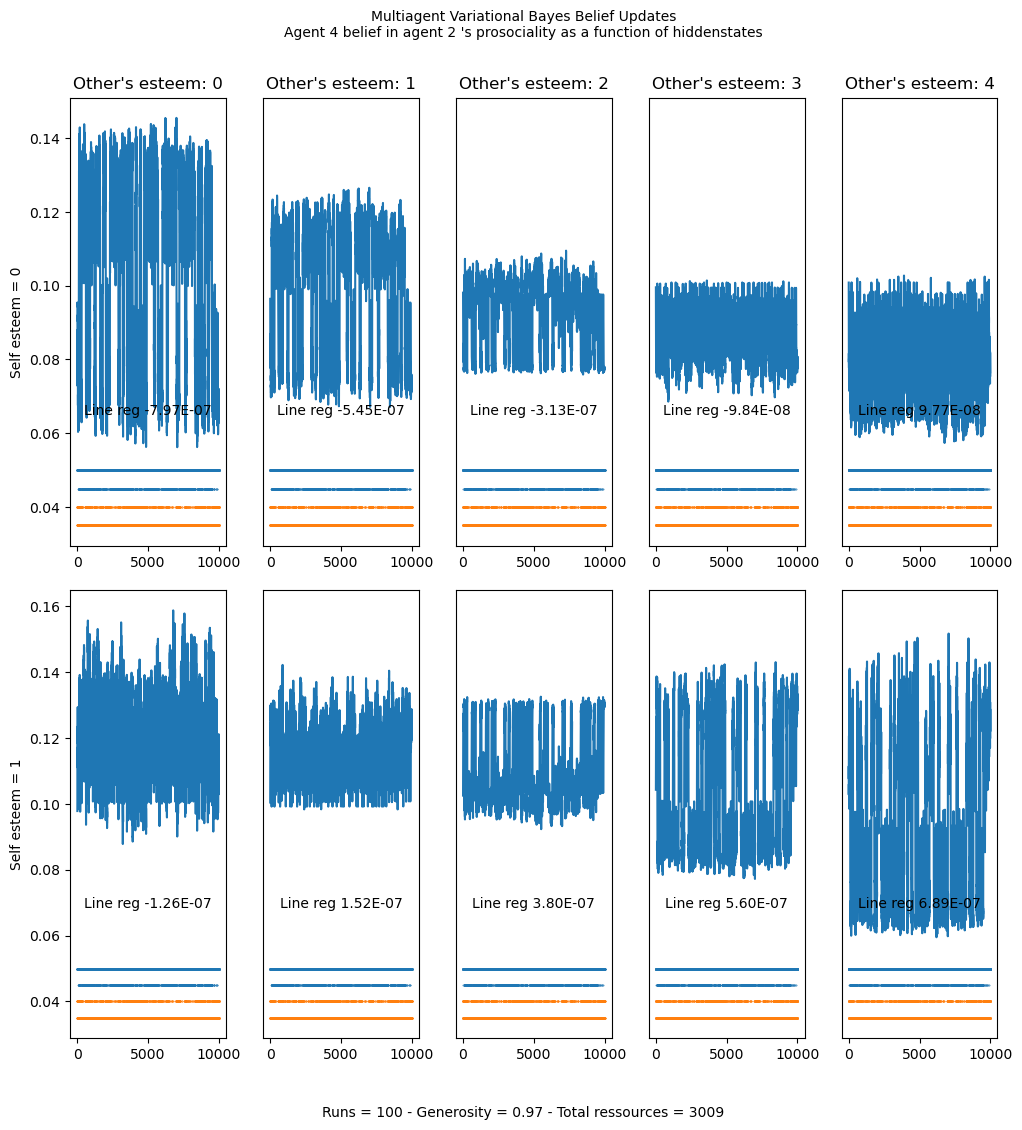

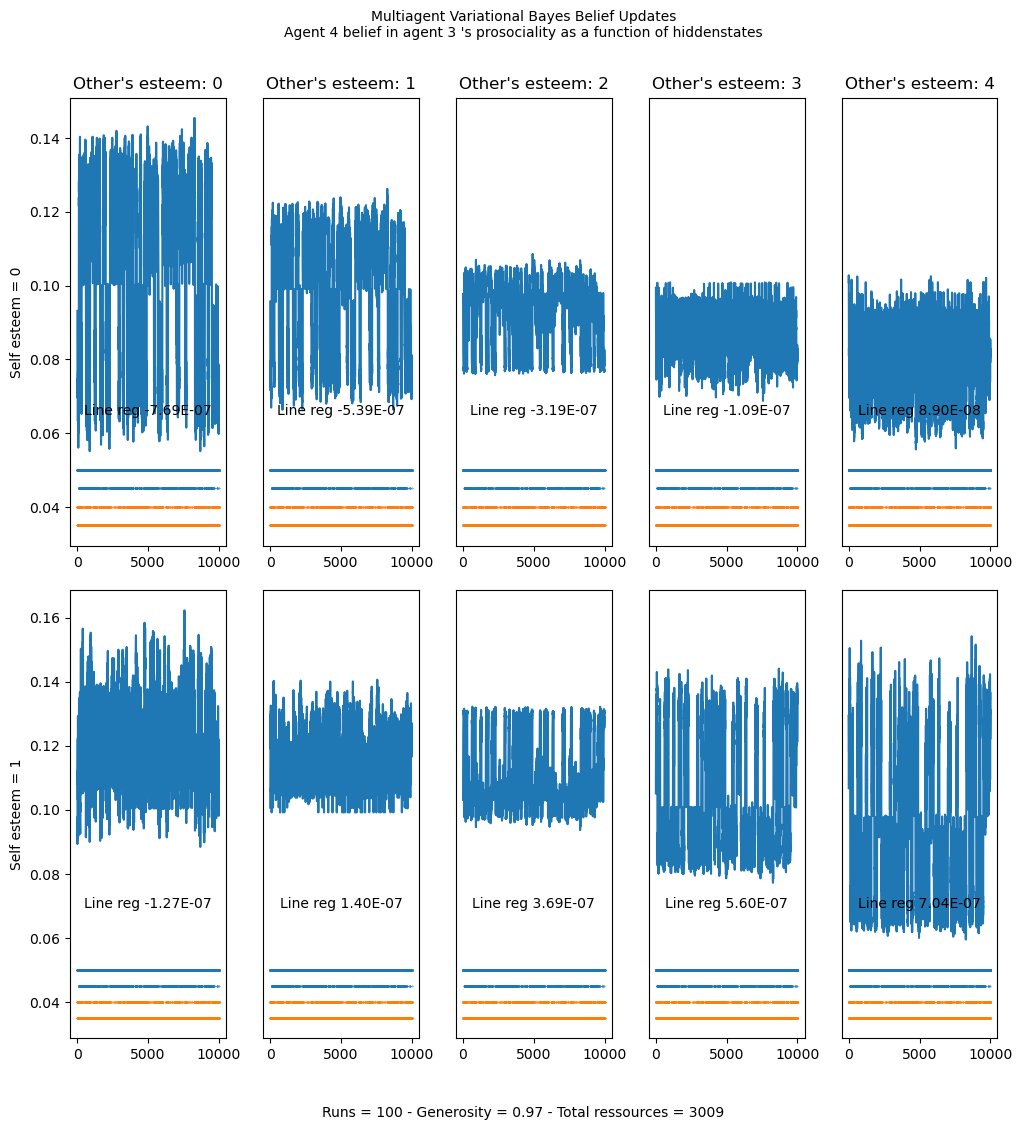

In [18]:


tracked_beliefs = open_file(DIRNAME, "beliefs_in_others_proportionality.json")
tracked_action_pairs = open_file(DIRNAME, "action_pairs.json")
gen = open_file(DIRNAME, "generosity.json")
res = open_file(DIRNAME, "ressources.json")
#agent_data = open_file(DIRNAME, "agent_data.json")
    
all_res = []
#agent_data = []
    
for r, round in enumerate(tracked_action_pairs):
    for a, agent in enumerate(round):
        for o, other in enumerate(agent):
            if other[0] == "proportionate":
                tracked_action_pairs[r][a][o][0] = 0.05
            else:
                tracked_action_pairs[r][a][o][0] = 0.045
            if other[1] == "proportionate":
                tracked_action_pairs[r][a][o][1] = 0.04
            else:
                tracked_action_pairs[r][a][o][1] = 0.035

for p in range(NUM_AGENTS):
    tot_res = []
    for r in res:
        tot_res.append(r[p])
    all_res.append(sum(tot_res)/NUM_ROUNDS)
    
for agent in range(NUM_AGENTS):
        
    list = np.arange(0, NUM_AGENTS, 1).tolist()
    list.pop(agent)
        
    other_data = []
        
    for other, item in enumerate(list):
    
        labels_y = ['Self esteem = 0', 'Self esteem = 1']
            
        # Set up the plot
        #################
                
        fig, axs = plt.subplots(2, 5, sharey='row', figsize=(10, 10))
        fig.tight_layout()
        fig.text(0.5, -0.04, 'Runs = %d - Generosity = %.2f - Total ressources = %d' % (NUM_ROUNDS, gen[0][agent], all_res[agent]), ha='center')
        fig.text(0.5, 1.04, 'Multiagent Variational Bayes Belief Updates\nAgent %d belief in agent %d \'s prosociality as a function of hiddenstates' % (agent, item), ha='center')
    
        # Plot the subplots
        ###################
        r = 0
        c = 0
        
        viz_data = []
            
        for i in range(10):
            data = []
            action_a = []
            action_o = []
                
            for round, d in enumerate(tracked_beliefs):
                    
                s = d[agent][other][i]
                aa = tracked_action_pairs[round][agent][other][0]
                ao = tracked_action_pairs[round][agent][other][1]
                data.append(s)
                action_a.append(aa)
                action_o.append(ao)
                        
            if i < 5:
                r = 0
                c = i
            else:
                r = 1
                c = i - 5
                
            x = np.arange(0, len(data)).tolist()
                
            axs[r, c].plot(data)
            axs[r, c].scatter(x, action_a, s=0.1)
            axs[r, c].scatter(x, action_o, s=0.1)
    
            slope, intercept, rv, p, se = linregress(x, data)

            sign = ''
                
            if p < 0.05:
                if slope >= 0:
                    sign = '+'
                else:
                    sign = '-'
            else:
                sign = 'o'
                    
            #viz_data.append([agent, item, i, sign])
                
            sl = ''
            prv = ''
            if slope > 0:
                sl = '+'
            if rv > 0:
                prv = '+'
                    
            print('###########################################################################################################################')
            print('# Agent %d / other %d / state %d: slope %s%.2E - intercept %.2E - Pearsonr %s%.2E - p-value %.2E - SE %.2E #' % (agent, item, i, sl, slope, intercept, prv, rv, p, se))
                
            axs[r, c].text(0.5, 0.3, 'Line reg %.2E' % slope, horizontalalignment='center', verticalalignment='center', transform=axs[r, c].transAxes)
                
                
            if i < 5:
                axs[r, c].set_title('Other\'s esteem: %d' % c)
                    
            axs[r, c].set_ylabel(labels_y[r])
                
            if c != 0:
                axs[r, c].axes.get_yaxis().set_visible(False)
    
        #other_data.append(viz_data)
    #agent_data.append(other_data)
        
print('###########################################################################################################################')
    
    
    
#save_file(DIRNAME, "agent_data.json", agent_data)




#################################################################################################################
# Agent 0 / other 1: slope -6.22E-05 - intercept 6.23E-01 - Pearsonr -3.91E-02 - p-value 9.11E-05 - SE 1.59E-05 #
#################################################################################################################
# Agent 0 / other 2: slope -4.17E-05 - intercept 5.42E-01 - Pearsonr -2.77E-02 - p-value 5.52E-03 - SE 1.50E-05 #
#################################################################################################################
# Agent 0 / other 3: slope -1.82E-05 - intercept 3.45E-01 - Pearsonr -1.55E-02 - p-value 1.20E-01 - SE 1.17E-05 #
#################################################################################################################
# Agent 0 / other 4: slope -1.06E-05 - intercept 4.41E-01 - Pearsonr -7.46E-03 - p-value 4.56E-01 - SE 1.42E-05 #
########################################################################################

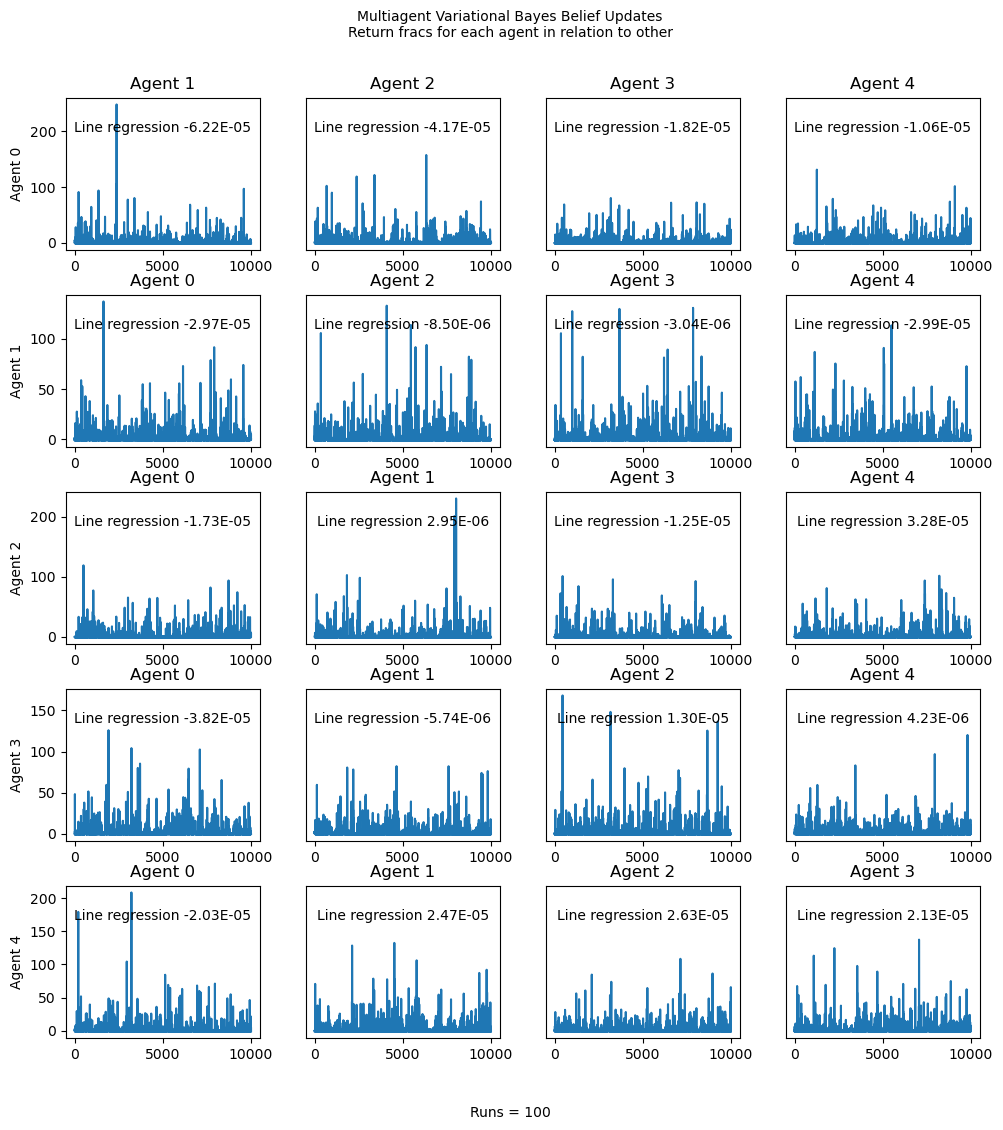

In [19]:
tracked_fracs = open_file(DIRNAME, "return_fracs.json")

labels_y = ['Self esteem = 0', 'Self esteem = 1']

# Set up the plot
#################

fig, axs = plt.subplots(5, 4, sharey='row', figsize=(10, 10))
fig.tight_layout()
fig.text(0.5, -0.04, 'Runs = %d' % NUM_ROUNDS, ha='center')
fig.text(0.5, 1.04, 'Multiagent Variational Bayes Belief Updates\nReturn fracs for each agent in relation to other', ha='center')

# Plot the subplots
###################
for i in range(NUM_AGENTS):
    r = range(0, NUM_AGENTS)
    list = np.arange(0, 5, 1).tolist()
    list.pop(i)
    
    for c, other in enumerate(list):
        data = []
        for a in tracked_fracs:
            #print('a', a)
            s = a[i][other]
            data.append(s)
        
        axs[i, c].plot(data)
        
        x = np.arange(0, len(data)).tolist()
            
        slope, intercept, rv, p, se = linregress(x, data)
            
        sl = ''
        prv = ''
        if slope > 0:
            sl = '+'
        if rv > 0:
            prv = '+'
                
        print('#################################################################################################################')
        print('# Agent %d / other %d: slope %s%.2E - intercept %.2E - Pearsonr %s%.2E - p-value %.2E - SE %.2E #' % (i, other, sl, slope, intercept, prv, rv, p, se))
            
        
        axs[i, c].text(0.5, 0.8, 'Line regression %.2E' % slope, horizontalalignment='center', verticalalignment='center', transform=axs[i, c].transAxes)

        axs[i, c].set_title('Agent %d' % other)
    
        axs[i, c].set_ylabel('Agent %d'% i)

        if c != 0:
            axs[i, c].axes.get_yaxis().set_visible(False)

print('#################################################################################################################')



#################################################################################################################
# Agent 0 / other 1: slope -3.45E-04 - intercept 6.41E-02 - Pearsonr -6.73E-03 - p-value 9.47E-01 - SE 5.18E-03 #
#################################################################################################################
# Agent 0 / other 2: slope -4.68E-03 - intercept 4.55E-01 - Pearsonr -5.01E-02 - p-value 6.20E-01 - SE 9.43E-03 #
#################################################################################################################
# Agent 0 / other 3: slope +1.41E-02 - intercept 4.02E-01 - Pearsonr +7.30E-02 - p-value 4.71E-01 - SE 1.95E-02 #
#################################################################################################################
# Agent 0 / other 4: slope +1.72E-02 - intercept 2.13E-01 - Pearsonr +9.97E-02 - p-value 3.24E-01 - SE 1.74E-02 #
########################################################################################

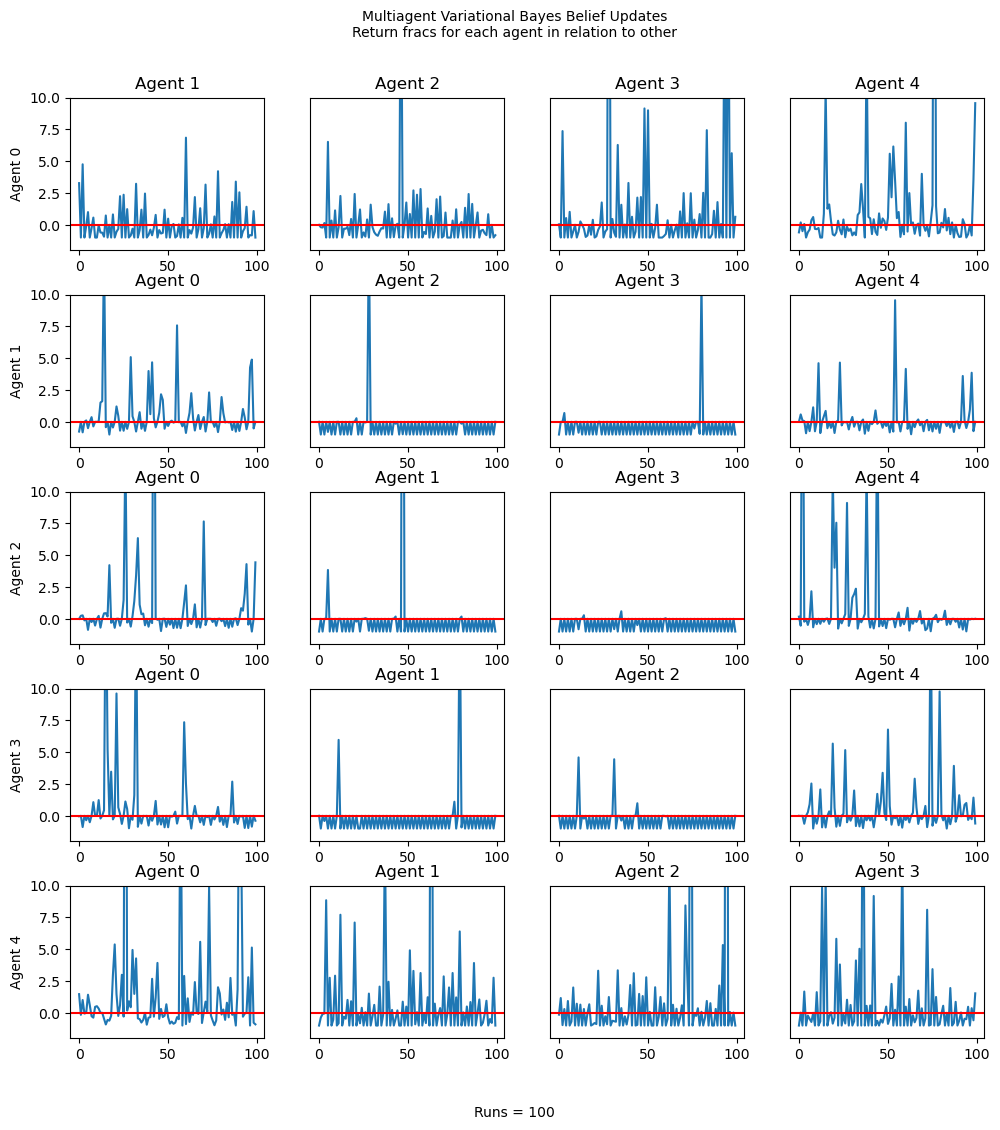

In [19]:
tracked_fracs = open_file(DIRNAME, "return_fracs.json")
tracked_fracs = tracked_fracs[-100:]



labels_y = ['Self esteem = 0', 'Self esteem = 1']

# Set up the plot
#################

fig, axs = plt.subplots(5, 4, sharey='row', figsize=(10, 10))
fig.tight_layout()
fig.text(0.5, -0.04, 'Runs = %d' % NUM_ROUNDS, ha='center')
fig.text(0.5, 1.04, 'Multiagent Variational Bayes Belief Updates\nReturn fracs for each agent in relation to other', ha='center')

# Plot the subplots
###################
for i in range(NUM_AGENTS):
    r = range(0, NUM_AGENTS)
    list = np.arange(0, 5, 1).tolist()
    list.pop(i)
    
    for c, other in enumerate(list):
        data = []
        for a in tracked_fracs:
            #print('a', a)
            s = a[i][other]
            data.append(s)

        axs[i, c].set_ylim([-2.0, 10.0])

        axs[i, c].plot(data)
        axs[i, c].axline((0.5, 0.0), slope=0.0, color='red', label='Zero');
        
        x = np.arange(0, len(data)).tolist()
            
        slope, intercept, rv, p, se = linregress(x, data)
            
        sl = ''
        prv = ''
        if slope > 0:
            sl = '+'
        if rv > 0:
            prv = '+'
                
        print('#################################################################################################################')
        print('# Agent %d / other %d: slope %s%.2E - intercept %.2E - Pearsonr %s%.2E - p-value %.2E - SE %.2E #' % (i, other, sl, slope, intercept, prv, rv, p, se))
            
        
        #axs[i, c].text(0.5, 0.8, 'Line regression %.2E' % slope, horizontalalignment='center', verticalalignment='center', transform=axs[i, c].transAxes)

        axs[i, c].set_title('Agent %d' % other)
    
        axs[i, c].set_ylabel('Agent %d'% i)

        if c != 0:
            axs[i, c].axes.get_yaxis().set_visible(False)

print('#################################################################################################################')



Slope:  -15.142151129357146 p:  0.019170684447236637 Pearson correlation coefficient:  -0.10472011489047894


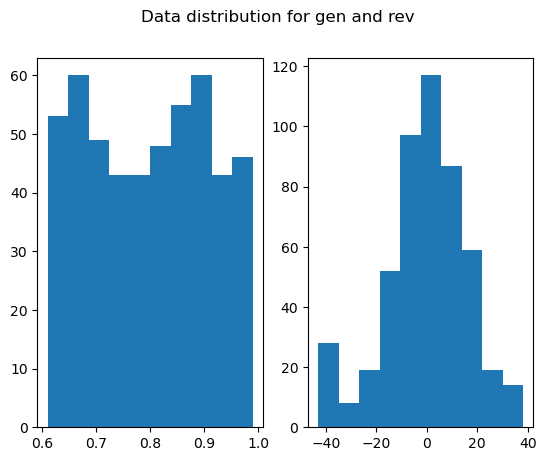

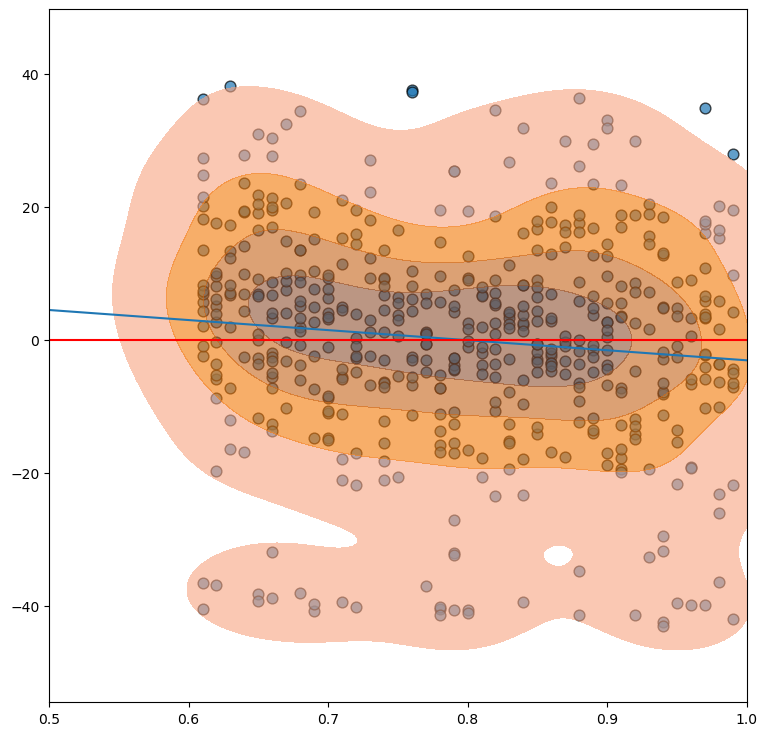

In [30]:
tracked_gen_rev = open_file(DIRNAME, "tracked_gen_rev.json")

# Data
x = tracked_gen_rev[0]
y = tracked_gen_rev[1]

# Data distribution
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Data distribution for gen and rev')
ax1.hist(x)
ax2.hist(y)

# Initialize layout
fig, ax = plt.subplots(figsize=(9, 9))
plt.xlim(left=0.5)

slope, intercept, rv, p, se = linregress(x, y)

print('Slope: ', slope, 'p: ',  p, 'Pearson correlation coefficient: ', rv)

# Add scatterplot
ax.scatter(x, y, s=60, alpha=0.7, edgecolors="k")

sns.kdeplot(
    x=x,
    y=y,
    levels=5,
    fill=True,
    alpha=0.6,
    cut=2,
    ax=ax,
)

ax.axline((0, intercept), slope=slope, color='C0', label='by slope');
ax.axline((0.5, 0.0), slope=0.0, color='red', label='Zero');




Slope:  0.0021958433423193216 p:  0.7451276994467113 Pearson correlation coefficient:  0.014573298812520083


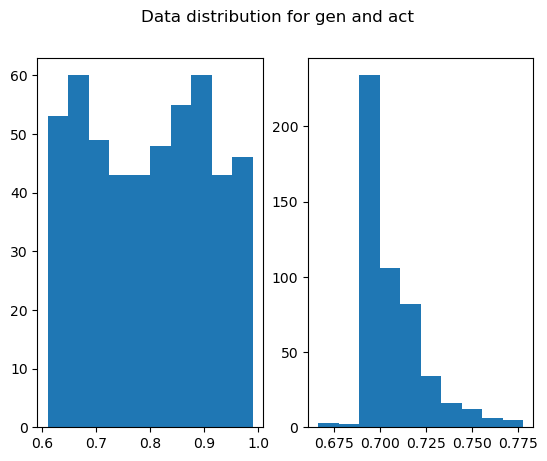

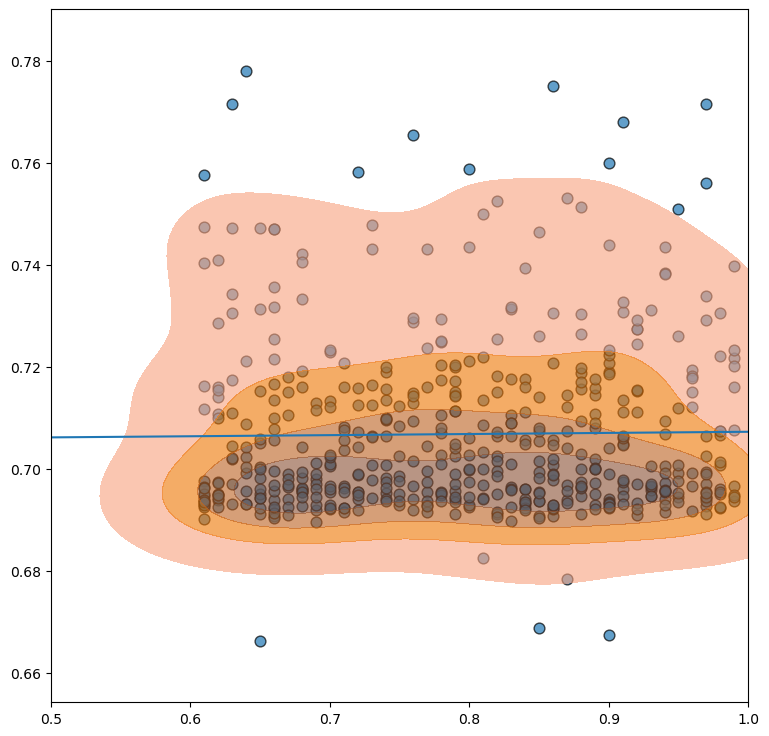

In [29]:
tracked_gen_act = open_file(DIRNAME, "tracked_gen_act.json")

# Data
x = tracked_gen_act[0]
y = tracked_gen_act[1]

# Data distribution
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Data distribution for gen and act')
ax1.hist(x)
ax2.hist(y)

slope, intercept, rv, p, se = linregress(x, y)

print('Slope: ', slope, 'p: ',  p, 'Pearson correlation coefficient: ', rv)

# Initialize layout
fig, ax = plt.subplots(figsize=(9, 9))
plt.xlim(left=0.5)

# Add scatterplot
ax.scatter(x, y, s=60, alpha=0.7, edgecolors="k")


sns.kdeplot(
    x=x,
    y=y,
    levels=5,
    fill=True,
    alpha=0.6,
    cut=2,
    ax=ax,
)

ax.axline((0.0, intercept), slope=slope, color='C0', label='by slope');




#######################################################################################################
# Agent 0: slope +2.70E-05 - intercept 2.94E+01 - Pearsonr +9.81E-03 - p-value 3.27E-01 - SE 2.75E-05 #
#######################################################################################################
# Agent 1: slope +1.44E-06 - intercept 3.00E+01 - Pearsonr +5.25E-04 - p-value 9.58E-01 - SE 2.74E-05 #
#######################################################################################################
# Agent 2: slope +5.17E-06 - intercept 3.00E+01 - Pearsonr +1.91E-03 - p-value 8.48E-01 - SE 2.70E-05 #
#######################################################################################################
# Agent 3: slope -5.32E-05 - intercept 3.06E+01 - Pearsonr -1.91E-02 - p-value 5.66E-02 - SE 2.79E-05 #
#######################################################################################################
# Agent 4: slope +6.89E-05 - intercept 2.99E+01 - Pearsonr +2.51

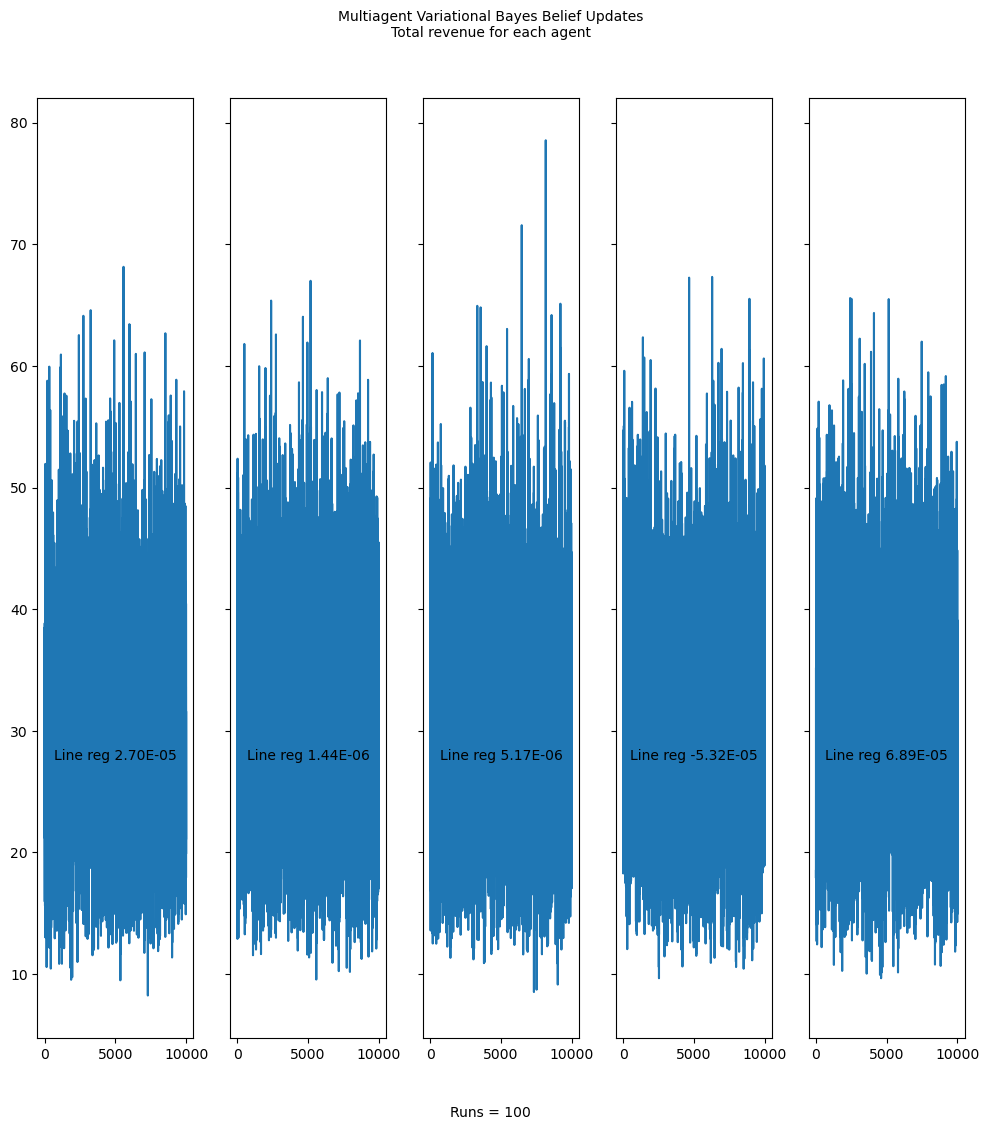

In [22]:
tracked_tot_rev = open_file(DIRNAME, "total_revenue.json")
gen = open_file(DIRNAME, "generosity.json")

summation = []
average = []

# Set up the plot
#################

fig, axs = plt.subplots(1, 5, sharey='row', figsize=(10, 10))
fig.tight_layout()
fig.text(0.5, -0.04, 'Runs = %d' % NUM_ROUNDS, ha='center')
fig.text(0.5, 1.04, 'Multiagent Variational Bayes Belief Updates\nTotal revenue for each agent', ha='center')

# Plot the subplots
###################
for i in range(NUM_AGENTS):
    data = []
    for a in tracked_tot_rev:
            #print('a', a)
            s = a[i]
            data.append(s)

    summation.append(sum(data))
    average.append(sum(data)/len(data))
   
    axs[i].plot(data)
        
    x = np.arange(0, len(data)).tolist()
            
    slope, intercept, rv, p, se = linregress(x, data)
            
    sl = ''
    prv = ''
    if slope > 0:
        sl = '+'
    if rv > 0:
        prv = '+'
                
    print('#######################################################################################################')
    print('# Agent %d: slope %s%.2E - intercept %.2E - Pearsonr %s%.2E - p-value %.2E - SE %.2E #' % (i, sl, slope, intercept, prv, rv, p, se))
    
    axs[i].text(0.5, 0.3, 'Line reg %.2E' % slope, horizontalalignment='center', verticalalignment='center', transform=axs[i].transAxes)

print('#######################################################################################################')
print()
print()
print('######################################################################################################################')
print('#           #       agent 0      #      agent 1       #      agent 2       #       agent 3      #       agent 4      #')
print('######################################################################################################################')
print('#   gen     #       %.2f         #      %.2f          #      %.2f          #       %.2f         #       %.2f         #' % (gen[0][0], gen[0][1], gen[0][2], gen[0][3], gen[0][4]))
print('######################################################################################################################')
print('#   Sum     #      %.2f    #     %.2f     #     %.2f     #      %.2f    #      %.2f    #' % (summation[0], summation[1], summation[2], summation[3], summation[4]))
print('######################################################################################################################')
print('#   Avg     #       %.2f        #      %.2f         #      %.2f         #       %.2f        #       %.2f        #' % (average[0], average[1], average[2], average[3], average[4]))
print('######################################################################################################################')





In [23]:
gen = open_file(DIRNAME, "generosity.json")
agd = open_file(DIRNAME, "agent_data.json")

print('######################################################################################################################')
print('#           #       agent 0      #      agent 1       #      agent 2       #       agent 3      #       agent 4      #')
print('######################################################################################################################')
print('#           #       gen %.2f     #      gen %.2f      #      gen %.2f      #       gen %.2f     #       gen %.2f     #' % (gen[0][0], gen[0][1], gen[0][2], gen[0][3], gen[0][4]))
print('######################################################################################################################')
print('#  agent 0  ###################### %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  # ' % (agd[0][0][0][3], agd[0][0][1][3], agd[0][0][2][3], agd[0][0][3][3], agd[0][0][4][3], agd[0][1][0][3], agd[0][1][1][3], agd[0][1][2][3], agd[0][1][3][3], agd[0][1][4][3], agd[0][2][0][3], agd[0][2][1][3], agd[0][2][2][3], agd[0][2][3][3], agd[0][2][4][3], agd[0][3][0][3], agd[0][3][1][3], agd[0][3][2][3], agd[0][3][3][3], agd[0][3][4][3]))
print('#           ###################### %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  # ' % (agd[0][0][5][3], agd[0][0][6][3], agd[0][0][7][3], agd[0][0][8][3], agd[0][0][9][3], agd[0][1][5][3], agd[0][1][6][3], agd[0][1][7][3], agd[0][1][8][3], agd[0][1][9][3], agd[0][2][5][3], agd[0][2][6][3], agd[0][2][7][3], agd[0][2][8][3], agd[0][2][9][3], agd[0][3][5][3], agd[0][3][6][3], agd[0][3][7][3], agd[0][3][8][3], agd[0][3][9][3]))
print('######################################################################################################################')
print('#  agent 1  # %s | %s | %s | %s | %s  ###################### %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  # ' % (agd[1][0][0][3], agd[1][0][1][3], agd[1][0][2][3], agd[1][0][3][3], agd[1][0][4][3], agd[1][1][0][3], agd[1][1][1][3], agd[1][1][2][3], agd[1][1][3][3], agd[1][1][4][3], agd[1][2][0][3], agd[1][2][1][3], agd[1][2][2][3], agd[1][2][3][3], agd[1][2][4][3], agd[1][3][0][3], agd[1][3][1][3], agd[1][3][2][3], agd[1][3][3][3], agd[1][3][4][3]))
print('#           # %s | %s | %s | %s | %s  ###################### %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  # ' % (agd[1][0][5][3], agd[1][0][6][3], agd[1][0][7][3], agd[1][0][8][3], agd[1][0][9][3], agd[1][1][5][3], agd[1][1][6][3], agd[1][1][7][3], agd[1][1][8][3], agd[1][1][9][3], agd[1][2][5][3], agd[1][2][6][3], agd[1][2][7][3], agd[1][2][8][3], agd[1][2][9][3], agd[1][3][5][3], agd[1][3][6][3], agd[1][3][7][3], agd[1][3][8][3], agd[1][3][9][3]))
print('######################################################################################################################')
print('#  agent 2  # %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  ###################### %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  # ' % (agd[2][0][0][3], agd[2][0][1][3], agd[2][0][2][3], agd[2][0][3][3], agd[2][0][4][3], agd[2][1][0][3], agd[2][1][1][3], agd[2][1][2][3], agd[2][1][3][3], agd[2][1][4][3], agd[2][2][0][3], agd[2][2][1][3], agd[2][2][2][3], agd[2][2][3][3], agd[2][2][4][3], agd[2][3][0][3], agd[2][3][1][3], agd[2][3][2][3], agd[2][3][3][3], agd[2][3][4][3]))
print('#           # %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  ###################### %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  # ' % (agd[2][0][5][3], agd[2][0][6][3], agd[2][0][7][3], agd[2][0][8][3], agd[2][0][9][3], agd[2][1][5][3], agd[2][1][6][3], agd[2][1][7][3], agd[2][1][8][3], agd[2][1][9][3], agd[2][2][5][3], agd[2][2][6][3], agd[2][2][7][3], agd[2][2][8][3], agd[2][2][9][3], agd[2][3][5][3], agd[2][3][6][3], agd[2][3][7][3], agd[2][3][8][3], agd[2][3][9][3]))
print('######################################################################################################################')
print('#  agent 3  # %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  ###################### %s | %s | %s | %s | %s  # ' % (agd[3][0][0][3], agd[3][0][1][3], agd[3][0][2][3], agd[3][0][3][3], agd[3][0][4][3], agd[3][1][0][3], agd[3][1][1][3], agd[3][1][2][3], agd[3][1][3][3], agd[3][1][4][3], agd[3][2][0][3], agd[3][2][1][3], agd[3][2][2][3], agd[3][2][3][3], agd[3][2][4][3], agd[3][3][0][3], agd[3][3][1][3], agd[3][3][2][3], agd[3][3][3][3], agd[3][3][4][3]))
print('#           # %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  ###################### %s | %s | %s | %s | %s  # ' % (agd[3][0][5][3], agd[3][0][6][3], agd[3][0][7][3], agd[3][0][8][3], agd[3][0][9][3], agd[3][1][5][3], agd[3][1][6][3], agd[3][1][7][3], agd[3][1][8][3], agd[3][1][9][3], agd[3][2][5][3], agd[3][2][6][3], agd[3][2][7][3], agd[3][2][8][3], agd[3][2][9][3], agd[3][3][5][3], agd[3][3][6][3], agd[3][3][7][3], agd[3][3][8][3], agd[3][3][9][3]))
print('######################################################################################################################')
print('#  agent 4  # %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  ###################### ' % (agd[4][0][0][3], agd[4][0][1][3], agd[4][0][2][3], agd[4][0][3][3], agd[4][0][4][3], agd[4][1][0][3], agd[4][1][1][3], agd[4][1][2][3], agd[4][1][3][3], agd[4][1][4][3], agd[4][2][0][3], agd[4][2][1][3], agd[4][2][2][3], agd[4][2][3][3], agd[4][2][4][3], agd[4][3][0][3], agd[4][3][1][3], agd[4][3][2][3], agd[4][3][3][3], agd[4][3][4][3]))
print('#           # %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  # %s | %s | %s | %s | %s  ###################### ' % (agd[4][0][5][3], agd[4][0][6][3], agd[4][0][7][3], agd[4][0][8][3], agd[4][0][9][3], agd[4][1][5][3], agd[4][1][6][3], agd[4][1][7][3], agd[4][1][8][3], agd[4][1][9][3], agd[4][2][5][3], agd[4][2][6][3], agd[4][2][7][3], agd[4][2][8][3], agd[4][2][9][3], agd[4][3][5][3], agd[4][3][6][3], agd[4][3][7][3], agd[4][3][8][3], agd[4][3][9][3]))
print('######################################################################################################################')
print()
print()
print('###############################################')
print('#          #  0   #  1   #  2   #  3   #  4   #')
print('###############################################')
print('# agent 0  ########  %d   #  %d   #  %d   #  %d   #' % (np.argmax(agents[0]['belief'][0]), np.argmax(agents[0]['belief'][1]), np.argmax(agents[0]['belief'][2]), np.argmax(agents[0]['belief'][3])))
print('###############################################')
print('# agent 1  #  %d   ########  %d   #  %d   #  %d   #' % (np.argmax(agents[1]['belief'][0]), np.argmax(agents[1]['belief'][1]), np.argmax(agents[1]['belief'][2]), np.argmax(agents[1]['belief'][3])))
print('###############################################')
print('# agent 2  #  %d   #  %d   ########  %d   #  %d   #' % (np.argmax(agents[2]['belief'][0]), np.argmax(agents[2]['belief'][1]), np.argmax(agents[2]['belief'][2]), np.argmax(agents[2]['belief'][3])))
print('###############################################')
print('# agent 3  #  %d   #  %d   #  %d   ########  %d   #' % (np.argmax(agents[3]['belief'][0]), np.argmax(agents[3]['belief'][1]), np.argmax(agents[3]['belief'][2]), np.argmax(agents[3]['belief'][3])))
print('###############################################')
print('# agent 4  #  %d   #  %d   #  %d   #  %d   ########' % (np.argmax(agents[4]['belief'][0]), np.argmax(agents[4]['belief'][1]), np.argmax(agents[4]['belief'][2]), np.argmax(agents[4]['belief'][3])))
print()
print()
print('###############################################')
print('#          #  0   #  1   #  2   #  3   #  4   #')
print('###############################################')
print('# agent 0  ######## %.2f # %.2f # %.2f # %.2f #' % (np.max(agents[0]['belief'][0]), np.max(agents[0]['belief'][1]), np.max(agents[0]['belief'][2]), np.max(agents[0]['belief'][3])))
print('###############################################')
print('# agent 1  # %.2f ######## %.2f # %.2f # %.2f #' % (np.max(agents[1]['belief'][0]), np.max(agents[1]['belief'][1]), np.max(agents[1]['belief'][2]), np.max(agents[1]['belief'][3])))
print('###############################################')
print('# agent 2  # %.2f # %.2f ######## %.2f # %.2f #' % (np.max(agents[2]['belief'][0]), np.max(agents[2]['belief'][1]), np.max(agents[2]['belief'][2]), np.max(agents[2]['belief'][3])))
print('###############################################')
print('# agent 3  # %.2f # %.2f # %.2f ######## %.2f #' % (np.max(agents[3]['belief'][0]), np.max(agents[3]['belief'][1]), np.max(agents[3]['belief'][2]), np.max(agents[3]['belief'][3])))
print('###############################################')
print('# agent 4  # %.2f # %.2f # %.2f # %.2f ########' % (np.max(agents[4]['belief'][0]), np.max(agents[4]['belief'][1]), np.max(agents[4]['belief'][2]), np.max(agents[4]['belief'][3])))





######################################################################################################################
#           #       agent 0      #      agent 1       #      agent 2       #       agent 3      #       agent 4      #
######################################################################################################################
#           #       gen 0.82     #      gen 0.88      #      gen 0.81      #       gen 0.61     #       gen 0.97     #
######################################################################################################################
#  agent 0  ###################### + | + | o | - | -  # + | + | + | - | -  # + | + | o | - | -  # + | + | o | - | -  # 
#           ###################### + | + | o | - | -  # + | + | - | - | -  # + | + | o | - | -  # + | + | - | - | -  # 
######################################################################################################################
#  agent 1  # - | - | - | - | -  #############

In [24]:


gen = open_file(DIRNAME, "generosity.json")
agd = open_file(DIRNAME, "agent_data.json")




Slope:  0.022739278042163448 p:  4.016961119419402e-63 Pearson correlation coefficient:  0.3624032158297846


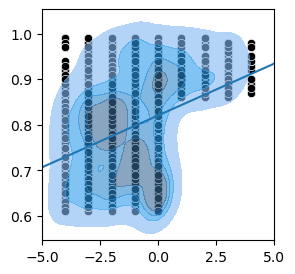

In [27]:
tracked_precision = open_file(DIRNAME, "precision.json")

x = []
y = []

for list in tracked_precision:
    for item in list:
        o_list = [4, 7, 10, 13]
        for ect in o_list:
            y.append(item[0])
            x.append(int(item[ect]))

slope, intercept, rv, p, se = linregress(x, y)

print('Slope: ',slope, 'p: ', p, 'Pearson correlation coefficient: ', rv)

fig, ax = plt.subplots(figsize=(3, 3))

sns.scatterplot(
    x=x,
    y=y,
    color="k",
    ax=ax,
)

sns.kdeplot(
    x=x,
    y=y,
    levels=5,
    fill=True,
    alpha=0.6,
    cut=2,
    ax=ax,
)

ax.axline((0, intercept), slope=slope, color='C0', label='by slope');


Slope:  -0.1147298955769217 p:  7.578180148115367e-133 Pearson correlation coefficient:  -0.5099460537194592


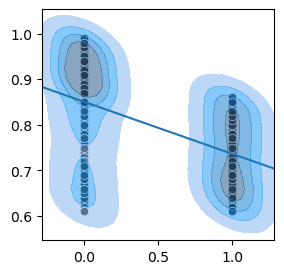

In [28]:
tracked_precision = open_file(DIRNAME, "precision.json")

x = []
y = []

for list in tracked_precision:
    for item in list:
        o_list = [3, 6, 9, 12]
        for ect in o_list:
            y.append(item[0])
            x.append(int(item[ect]))

slope, intercept, rv, p, se = linregress(x, y)

print('Slope: ', slope, 'p: ',  p, 'Pearson correlation coefficient: ', rv)

fig, ax = plt.subplots(figsize=(3, 3))

sns.scatterplot(
    x=x,
    y=y,
    color="k",
    ax=ax,
)

sns.kdeplot(
    x=x,
    y=y,
    levels=5,
    fill=True,
    alpha=0.6,
    cut=2,
    ax=ax,
)

ax.axline((0, intercept), slope=slope, color='C0', label='by slope');
